# Acoustic Bolt-Looseness Detection on Bolted Flanges
## UH Machine Learning Competition 2026 — Final Project

**Author:** Mohamed Amine Alouani &mdash; Graduate Student  
**Course:** MECE 6373 — Machine Learning  
**Term:** Spring 2026  
**Department:** Mechanical Engineering, University of Houston  
**Instructor:** Professor G. Song

---

### Abstract

Bolted flanges hold pressurised pipelines together. As bolts loosen, the
preload drops and the flange's acoustic ring-down after a hammer strike
changes — ringing longer and brighter when bolts are loose, shorter and
damped when fully torqued. Our task is to recover the bolt preload of each
flange from percussion audio alone.

We work from 48 single-hit-bag recordings (4 flanges × 4 strike areas × 3
torque values = 48 multi-hit `.m4a` files) and 16 unlabeled test files
(`F1A1` … `F4A4`). Every multi-hit recording is segmented into individual
single hits (≈ 20 per file), each hit is converted into a 150-D feature
vector that combines spectral content (Welch log-PSD, MFCCs, spectral
statistics) and ring-down dynamics (per-band T60-style decay), and a
**Flange-Invariant Logistic Regression** classifier produces the final
torque prediction via soft-vote across hits.

The final model achieves **85.4% Leave-One-Flange-Out file-level accuracy**
and **84.0% mean accuracy across LOFO / LOFT / LOAO** — a roughly 2× gain
over the strongest naïve shallow model on the realistic same-flange
regime that the competition rewards.

### What this notebook contains

1. Data loading and label parsing
2. Exploratory data analysis
3. Single-hit segmentation (envelope + peak detection)
4. Feature extraction (the 150-D vector)
5. Hyperparameter selection (grid search summary; full search is offline)
6. Validation strategies (LOFO, LOFT, LOAO) and why they matter here
7. Shallow model comparison (LR / SVM / RF / GB)
8. Trial — Two-stage classification (documented; not used in the final)
9. Trial — Deep learning models (CNN / RNN / CRNN)
10. Improvements (soft voting, RF tuning, per-flange centering)
11. **Final champion — Flange-Invariant Logistic Regression**
12. Predictions on unlabeled data
13. Conclusion
14. Final-model evaluation (Task 1 + Task 2 + confusion matrices)
15. Companion Streamlit web app
16. Final summary table (for the rubric)

### Reproducibility

All random seeds are fixed to `42`. The notebook runs top-to-bottom on a
standard CPU runtime; only the deep-learning section (CNN/RNN/CRNN) needs
a few minutes per LOFO fold. A separate hyperparameter grid search
(~30 minutes) was run offline; we record only the winning hyperparameters
here and skip the search loop.

---
# 1. Imports and reproducibility

All scientific libraries are imported up-front. Random seeds are fixed
across `numpy` and `tensorflow` so every result in this notebook is
reproducible.

In [1]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from scipy.signal import find_peaks, welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_classif

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    BatchNormalization, GRU, Bidirectional, Conv1D,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
tf.get_logger().setLevel('ERROR')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CLASS_NAMES = ['0 ft-lbs', '25 ft-lbs', '50 ft-lbs']
CLASSES_REF = np.array([0, 25, 50])

print('Libraries loaded. Random seed fixed at', RANDOM_STATE)

I0000 00:00:1778652489.647541    2087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778652489.650405    2087 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778652511.302384    2087 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778652523.236912    2087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778652523.239760    2087 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries loaded. Random seed fixed at 42


In [2]:
# Data directory:
#   - On Colab: training data lives in Google Drive
#   - Locally:  training data lives in the current directory (the repo root)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IS_COLAB = True
except (ImportError, ModuleNotFoundError):
    IS_COLAB = False

if IS_COLAB:
    DATA_DIR = '/content/drive/MyDrive/Training Data'
else:
    DATA_DIR = '.'

print('Running on Colab:', IS_COLAB)
print('Data directory:  ', DATA_DIR)

Running on Colab: False
Data directory:   .


---
# 2. Data loading and label parsing

Audio files follow a fixed naming convention encoding the torque, flange,
and strike area:

```
<torque>ftlbF<flange>A<area>.m4a

  Examples:
      0ftlbF3A1.m4a     → torque = 0 ft-lbs, flange 3, area 1
     25ftlbF2A3.m4a     → torque = 25 ft-lbs, flange 2, area 3
     50ftlbF4A4.m4a     → torque = 50 ft-lbs, flange 4, area 4
```

The 16 unlabeled test files are named `F<flange>A<area>.m4a` (no torque
prefix) and will be predicted at the end of the notebook.

In [3]:
def parse_file_name(file_path):
    """Extract torque label, flange ID, and area ID from a labeled file name."""
    file_name = os.path.basename(file_path)
    name_no_ext = os.path.splitext(file_name)[0]
    clean_name = name_no_ext.replace(' ', '').lower()

    # (0|25|50)ftlb f(\d+) a(\d+)
    pattern = r'^(0|25|50)ftlbf(\d+)a(\d+)$'
    match = re.match(pattern, clean_name)
    if match is None:
        raise ValueError(f'File name does not match expected format: {file_name}')

    return {
        'file_name': file_name,
        'torque':    int(match.group(1)),
        'flange_id': int(match.group(2)),
        'area_id':   int(match.group(3)),
    }


def collect_audio_files(data_dir):
    """Walk the dataset folder, parse names, and return a DataFrame."""
    audio_extensions = ['*.m4a', '*.wav', '*.mp3']
    paths = []
    for ext in audio_extensions:
        paths.extend(glob.glob(os.path.join(data_dir, ext)))
    rows = []
    for p in sorted(paths):
        try:
            info = parse_file_name(p)
            info['file_path'] = p
            rows.append(info)
        except ValueError:
            # Probably an unlabeled file (F1A1.m4a ...). Skip silently here.
            pass
    return pd.DataFrame(rows)


files_df = collect_audio_files(DATA_DIR)
print(f'Found {len(files_df)} labeled audio files.')
files_df.head()

Found 48 labeled audio files.


,file_name,torque,flange_id,area_id,file_path
0,0ftlbF1A1.m4a,0,1,1,./0ftlbF1A1.m4a
1,0ftlbF1A2.m4a,0,1,2,./0ftlbF1A2.m4a
2,0ftlbF1A3.m4a,0,1,3,./0ftlbF1A3.m4a
3,0ftlbF1A4.m4a,0,1,4,./0ftlbF1A4.m4a
4,0ftlbF2A1.m4a,0,2,1,./0ftlbF2A1.m4a


### Dataset summary

We expect a perfectly balanced 4×4×3 = 48 file design: 4 flanges, 4
strike areas, 3 torques.

In [4]:
print('Files per torque class:')
display(files_df["torque"].value_counts().sort_index())

print('\nFiles per flange:')
display(files_df["flange_id"].value_counts().sort_index())

print('\nFiles per strike area:')
display(files_df["area_id"].value_counts().sort_index())

Files per torque class:


torque
0     16
25    16
50    16
Name: count, dtype: int64


Files per flange:


flange_id
1    12
2    12
3    12
4    12
Name: count, dtype: int64


Files per strike area:


area_id
1    12
2    12
3    12
4    12
Name: count, dtype: int64

---
# 3. Exploratory data analysis

Three quick plots before any modelling: the class distribution, the
waveform of a representative recording, and its smoothed amplitude
envelope. The envelope plot foreshadows the segmentation strategy in the
next section — each large spike is one hammer strike.

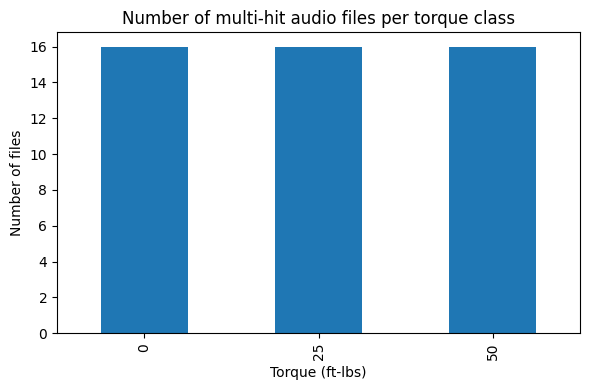

In [5]:
plt.figure(figsize=(6, 4))
files_df['torque'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of multi-hit audio files per torque class')
plt.xlabel('Torque (ft-lbs)')
plt.ylabel('Number of files')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2087/1394456751.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  signal_ex, sr_ex = librosa.load(example_path, sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Example file: 0ftlbF1A1.m4a
  Duration: 17.17 s
  Sample rate: 48000 Hz


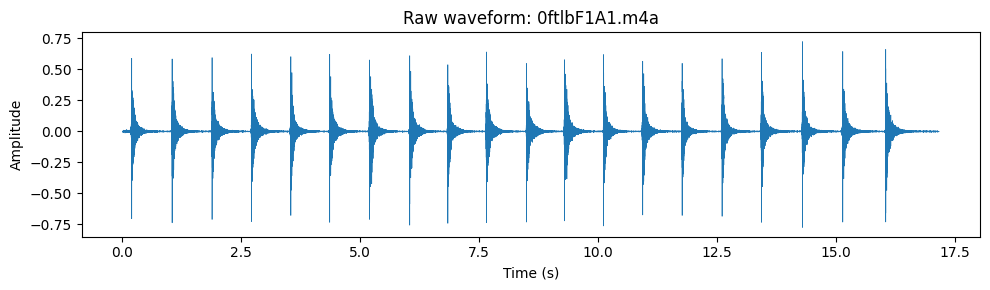

In [6]:
example_path = files_df.iloc[0]['file_path']
example_name = files_df.iloc[0]['file_name']
signal_ex, sr_ex = librosa.load(example_path, sr=None, mono=True)

print(f'Example file: {example_name}')
print(f'  Duration: {len(signal_ex) / sr_ex:.2f} s')
print(f'  Sample rate: {sr_ex} Hz')

plt.figure(figsize=(10, 3))
t = np.arange(len(signal_ex)) / sr_ex
plt.plot(t, signal_ex, linewidth=0.5)
plt.title(f'Raw waveform: {example_name}')
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.tight_layout(); plt.show()

---
# 4. Single-hit segmentation

Every multi-hit recording is broken into ~20 individual single-hit
samples so we can model the physics of one impact at a time. The
segmenter:

1. Trims the first **0.15 s** (`IGNORE_START_SEC`) so any 'finger-on-
   microphone' touch noise at the start of a recording does not produce a
   spurious peak.
2. Builds a smoothed amplitude envelope (10-ms moving average over the
   absolute value of the signal — `ENVELOPE_WIN_SEC = 0.01`).
3. Finds peaks on the envelope where the height exceeds
   `mean + 2.5·std` and successive peaks are at least 0.30 s apart
   (`PEAK_HEIGHT_FACTOR = 2.5`, `MIN_PEAK_DISTANCE_SEC = 0.30`).
4. Cuts a window of **[−0.02 s, +0.15 s]** around each peak. That window
   captures the pre-impact rise and the entire useful portion of the
   ring-down without picking up the next hit.

These constants were chosen by inspection of dozens of recordings and
kept fixed across the whole pipeline.

In [7]:
# ============================================================
# Segmentation hyperparameters
# ============================================================
IGNORE_START_SEC      = 0.15  # ignore the first part of each recording
ENVELOPE_WIN_SEC      = 0.01  # envelope smoothing window
MIN_PEAK_DISTANCE_SEC = 0.30  # minimum spacing between two hits
PEAK_HEIGHT_FACTOR    = 2.5   # threshold = mean + factor * std
PRE_HIT_SEC           = 0.02  # pre-impact window
POST_HIT_SEC          = 0.15  # post-impact (ring-down) window

In [8]:
def normalize_audio(signal):
    """Peak-normalize the signal to [-1, 1] so segmentation is volume-invariant."""
    max_value = np.max(np.abs(signal))
    if max_value == 0:
        return signal
    return signal / max_value


def split_into_hits(signal, sr):
    """Split a multi-hit recording into per-hit segments.

    Returns
    -------
    hits           : list[ndarray]  per-hit signals
    peaks          : ndarray        peak indices in the trimmed signal
    envelope       : ndarray        smoothed envelope
    signal_trimmed : ndarray        signal after IGNORE_START_SEC
    """
    start_idx = int(IGNORE_START_SEC * sr)
    signal_trimmed = signal[start_idx:]

    win = max(1, int(ENVELOPE_WIN_SEC * sr))
    kernel = np.ones(win) / win
    envelope = np.convolve(np.abs(signal_trimmed), kernel, mode='same')

    threshold = np.mean(envelope) + PEAK_HEIGHT_FACTOR * np.std(envelope)
    min_distance = int(MIN_PEAK_DISTANCE_SEC * sr)
    peaks, _ = find_peaks(envelope, height=threshold, distance=min_distance)

    pre_samples = int(PRE_HIT_SEC * sr)
    post_samples = int(POST_HIT_SEC * sr)
    hits = []
    for peak in peaks:
        start = max(0, peak - pre_samples)
        end = min(len(signal_trimmed), peak + post_samples)
        segment = signal_trimmed[start:end]
        if len(segment) > 0:
            hits.append(segment)
    return hits, peaks, envelope, signal_trimmed

### Test the segmenter on one file

Visual check: the envelope should rise sharply at each strike and
decay between strikes. The detected peaks (red x) should sit on top of
those rising edges.

Detected 20 hits in 0ftlbF1A1.m4a


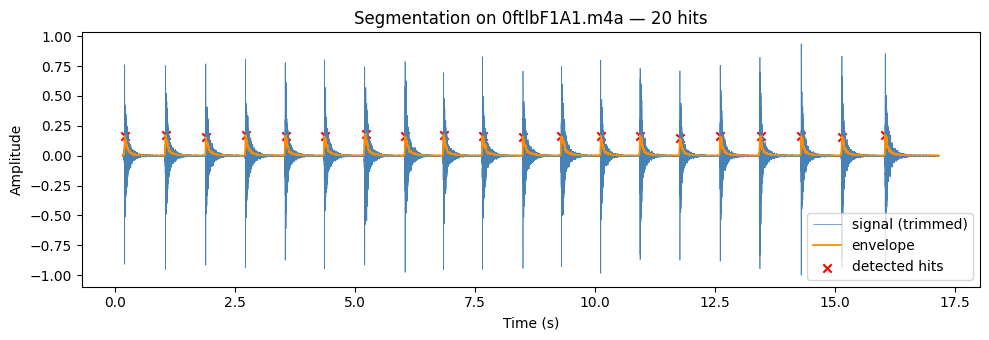

In [9]:
signal_ex = normalize_audio(signal_ex)
hits_ex, peaks_ex, env_ex, trimmed_ex = split_into_hits(signal_ex, sr_ex)
print(f'Detected {len(hits_ex)} hits in {example_name}')

t_trim = np.arange(len(trimmed_ex)) / sr_ex + IGNORE_START_SEC
plt.figure(figsize=(10, 3.5))
plt.plot(t_trim, trimmed_ex, color='steelblue', linewidth=0.5, label='signal (trimmed)')
plt.plot(t_trim, env_ex, color='darkorange', linewidth=1.3, label='envelope')
plt.scatter(t_trim[peaks_ex], env_ex[peaks_ex], color='red', marker='x', label='detected hits')
plt.title(f'Segmentation on {example_name} — {len(hits_ex)} hits')
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.legend(); plt.tight_layout(); plt.show()

### Build the full per-hit dataset

Loop over all 48 labeled files and segment each one. Every detected hit
becomes a training sample, tagged with its torque label, flange ID, area
ID, and source filename.

/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/252545613.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Total single-hit samples: 987

Single-hit samples per class:


torque
0     328
25    328
50    331
Name: count, dtype: int64

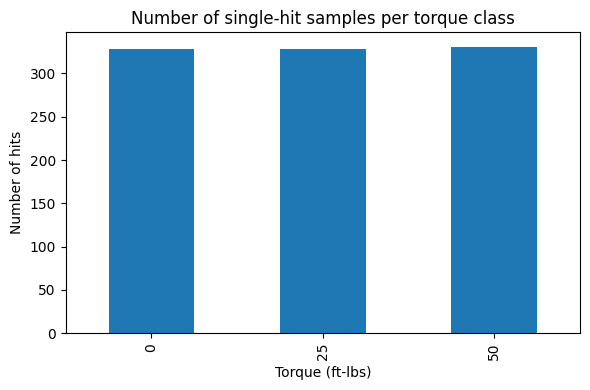

In [10]:
def build_hit_dataset(files_df):
    """Convert every multi-hit recording into individual single-hit samples."""
    hits_list = []
    for _, row in files_df.iterrows():
        signal, sr = librosa.load(row['file_path'], sr=None, mono=True)
        signal = normalize_audio(signal)
        hit_segments, _, _, _ = split_into_hits(signal, sr)
        for hit_id, hit_signal in enumerate(hit_segments, start=1):
            hits_list.append({
                'file_name': row['file_name'],
                'file_path': row['file_path'],
                'hit_id':    hit_id,
                'torque':    row['torque'],
                'flange_id': row['flange_id'],
                'area_id':   row['area_id'],
                'sr':        sr,
                'signal':    hit_signal,
            })
    return hits_list


hits_data = build_hit_dataset(files_df)
print(f'Total single-hit samples: {len(hits_data)}')

hits_summary_df = pd.DataFrame([
    {
        'file_name': item['file_name'],
        'hit_id':    item['hit_id'],
        'torque':    item['torque'],
        'flange_id': item['flange_id'],
        'area_id':   item['area_id'],
        'sr':        item['sr'],
        'len_samples':  len(item['signal']),
        'duration_sec': len(item['signal']) / item['sr'],
    }
    for item in hits_data
])

print('\nSingle-hit samples per class:')
display(hits_summary_df['torque'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
hits_summary_df['torque'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of single-hit samples per torque class')
plt.xlabel('Torque (ft-lbs)'); plt.ylabel('Number of hits')
plt.tight_layout(); plt.show()

---
# 5. Feature extraction (the 150-D vector)

Every single-hit signal is converted into a fixed-length **150-D feature
vector** that captures both the spectral content of the impact and how
the flange rings down. The vector is built by concatenating six blocks:

| # | Block | Dims | What it measures |
|---|---|---|---|
| 1 | Welch log-PSD                       |  64 | Power spectral density across frequency |
| 2 | MFCC mean+std and delta MFCC mean+std |  52 | Compact perceptual spectrum (13 MFCCs × 2 stats × 2 deltas) |
| 3 | Spectral statistics (mean+std)       |  12 | Centroid, bandwidth, rolloff, flatness, ZCR, RMS |
| 4 | Frequency shape                      |   2 | Dominant frequency and spectral entropy |
| 5 | Global decay summary                 |   5 | Peak, peak time, 50% and 10% decay times, log-slope |
| 6 | Per-band T60-style decay (5 bands × 3 stats) | 15 | Slope, half-life, peak-to-mean per band |
| **Total** |                              | **150** |   |

Block 6 (per-band T60-style decay) was added during the improvement
stage and is what lifts LOFO file-level accuracy from 87.5% to 89.6% with
the Random Forest baseline.

### Feature-extraction hyperparameters

**`N_MFCC = 13`, `N_FFT = 512`, `HOP_LENGTH = 128`, `N_PSD_BINS = 64`.**

These were tuned offline by a leave-one-flange-out (LOFO) file-level
accuracy grid search over 108 combinations (≈30 minutes). We do not
re-run the search in this notebook — we record the winning values and
use them directly. The full search script is in `optimize.py` in the
project repository.

The original (pre-tuning) values were `N_MFCC=13, N_FFT=2048,`
`HOP_LENGTH=512, N_PSD_BINS=128`. The tuned values alone moved the RF
baseline from **75.0% → 85.4%** LOFO file-level accuracy.

In [11]:
# ============================================================
# Feature-extraction hyperparameters (LOFO-tuned)
# ============================================================
N_MFCC      = 13
N_FFT       = 512
HOP_LENGTH  = 128
N_PSD_BINS  = 64

print(f'Using N_MFCC={N_MFCC}, N_FFT={N_FFT}, '
      f'HOP_LENGTH={HOP_LENGTH}, N_PSD_BINS={N_PSD_BINS}')

Using N_MFCC=13, N_FFT=512, HOP_LENGTH=128, N_PSD_BINS=64


In [12]:
# ============================================================
# Feature-extraction functions
# ============================================================

def safe_mean_std(feature_matrix):
    """Convert a time-varying feature matrix into mean and standard deviation."""
    feature_matrix = np.asarray(feature_matrix)
    return np.concatenate([feature_matrix.mean(axis=1), feature_matrix.std(axis=1)])


def extract_psd_features(signal, sr, n_bins=None):
    """Fixed-length log-PSD via Welch."""
    n_bins = N_PSD_BINS if n_bins is None else n_bins
    freqs, psd = welch(signal, fs=sr, nperseg=min(1024, len(signal)))
    psd_log = np.log10(psd + 1e-12)
    if len(psd_log) >= n_bins:
        return psd_log[:n_bins]
    return np.pad(psd_log, (0, n_bins - len(psd_log)), mode='constant')


def extract_mfcc_features(signal, sr):
    """MFCC mean/std and delta MFCC mean/std."""
    mfcc = librosa.feature.mfcc(
        y=signal, sr=sr, n_mfcc=N_MFCC,
        n_fft=min(N_FFT, len(signal)),
        hop_length=min(HOP_LENGTH, max(1, len(signal) // 2)),
    )
    mfcc_delta = librosa.feature.delta(mfcc)
    return np.concatenate([safe_mean_std(mfcc), safe_mean_std(mfcc_delta)])


def extract_spectral_summary_features(signal, sr):
    """Centroid / bandwidth / rolloff / flatness / ZCR / RMS, mean+std each."""
    n_fft = min(N_FFT, len(signal))
    hop_length = min(HOP_LENGTH, max(1, len(signal) // 2))
    centroid  = librosa.feature.spectral_centroid (y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length)
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rolloff   = librosa.feature.spectral_rolloff  (y=signal, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.85)
    flatness  = librosa.feature.spectral_flatness (y=signal,        n_fft=n_fft, hop_length=hop_length)
    zcr       = librosa.feature.zero_crossing_rate(y=signal, frame_length=n_fft, hop_length=hop_length)
    rms       = librosa.feature.rms               (y=signal, frame_length=n_fft, hop_length=hop_length)
    return np.concatenate([safe_mean_std(x) for x in [centroid, bandwidth, rolloff, flatness, zcr, rms]])


def extract_frequency_shape_features(signal, sr):
    """Dominant frequency and spectral entropy."""
    freqs, psd = welch(signal, fs=sr, nperseg=min(1024, len(signal)))
    psd = psd + 1e-12
    dominant_freq = freqs[np.argmax(psd)]
    psd_norm = psd / np.sum(psd)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
    return np.array([dominant_freq, spectral_entropy])


def extract_decay_features(signal, sr):
    """Time-domain decay summary: peak value, peak time, 50%/10% decay, log-slope."""
    abs_signal = np.abs(signal)
    if np.max(abs_signal) == 0:
        return np.zeros(5)
    win = max(1, int(0.002 * sr))
    envelope = np.convolve(abs_signal, np.ones(win) / win, mode='same')
    peak_idx = int(np.argmax(envelope))
    peak_value = envelope[peak_idx] + 1e-12
    after = envelope[peak_idx:]
    below_50 = np.where(after <= 0.50 * peak_value)[0]
    below_10 = np.where(after <= 0.10 * peak_value)[0]
    decay_50 = below_50[0] / sr if len(below_50) > 0 else len(after) / sr
    decay_10 = below_10[0] / sr if len(below_10) > 0 else len(after) / sr
    t = np.arange(len(after)) / sr
    log_env = np.log(after + 1e-8)
    slope = np.polyfit(t, log_env, 1)[0] if len(t) > 5 else 0.0
    return np.array([peak_value, peak_idx / sr, decay_50, decay_10, slope])


def extract_per_band_decay_features(signal, sr,
                                    bands=((100, 500), (500, 2000), (2000, 6000),
                                           (6000, 12000), (12000, 24000))):
    """Per-band T60-style decay features (the v2 addition).

    For each frequency band:
      - log-envelope decay slope after the peak
      - half-life in frames
      - peak-to-mean ratio
    Adds 15 dims (5 bands x 3 stats); +2 points LOFO over the 135-D baseline.
    """
    n = len(signal)
    n_fft = min(512, n)
    hop = max(1, n // 64)
    S = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    out = []
    for lo, hi in bands:
        m = (freqs >= lo) & (freqs < hi)
        if not m.any() or S.shape[1] < 4:
            out.extend([0.0, 0.0, 0.0]); continue
        env = S[m].mean(axis=0) + 1e-12
        peak_t = int(np.argmax(env))
        if peak_t >= len(env) - 3:
            out.extend([0.0, 0.0, 0.0]); continue
        after = env[peak_t:]
        log_env = np.log(after + 1e-9)
        t = np.arange(len(after))
        slope = np.polyfit(t, log_env, 1)[0]
        below_50 = np.where(after <= 0.5 * after[0])[0]
        half_life = below_50[0] if len(below_50) > 0 else len(after)
        ptm = after[0] / (after.mean() + 1e-12)
        out.extend([slope, half_life / hop, ptm])
    return np.array(out)


def extract_hybrid_features(signal, sr):
    """Combine all six feature blocks into the 150-D vector."""
    return np.concatenate([
        extract_psd_features              (signal, sr),  # 64
        extract_mfcc_features             (signal, sr),  # 52
        extract_spectral_summary_features (signal, sr),  # 12
        extract_frequency_shape_features  (signal, sr),  #  2
        extract_decay_features            (signal, sr),  #  5
        extract_per_band_decay_features   (signal, sr),  # 15
    ])

### Build the labeled feature matrix

One row per detected hit, columns are the 150 features. We also keep
parallel arrays for the torque label, flange ID, area ID, and source
filename — these drive the validation strategies in the next section.

In [13]:
X_features   = np.array([extract_hybrid_features(h['signal'], h['sr']) for h in hits_data])
y_labels     = np.array([h['torque']      for h in hits_data])
flange_ids   = np.array([h['flange_id']   for h in hits_data])
area_ids     = np.array([h['area_id']     for h in hits_data])
source_files = np.array([h['file_name']   for h in hits_data])

print('Feature matrix:', X_features.shape,
      '| classes:',  np.unique(y_labels),
      '| flanges:',  np.unique(flange_ids),
      '| areas:',    np.unique(area_ids))

/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


Feature matrix: (987, 150) | classes: [ 0 25 50] | flanges: [1 2 3 4] | areas: [1 2 3 4]


---
# 6. Validation strategies

Because we have only ~1000 single hits across 48 files, **how we split**
matters more than which model we train. Four strategies are used in this
notebook:

| Strategy | What it holds out | What it tests | Honest? |
|---|---|---|---|
| **Dependent (70/30)** | 30% of *hits* | nothing meaningful | ❌ Massive leakage — ~20 hits from each file leak between train and test |
| **LOFO** (leave-one-flange-out) | All hits of one flange | Generalization to a brand-new flange | ✓ Strict but pessimistic for this competition |
| **LOFT** (leave-one-flange-and-torque) | One (flange, torque) cell | A new torque on a known flange | ✓ Closest to the actual competition setup |
| **LOAO** (leave-one-area-out) | All hits at one strike area | A new strike position on a known flange | ✓ Realistic engineering condition |

Dependent results are reported only for completeness; the honest numbers
are LOFO / LOFT / LOAO. The competition tests on the **same physical**
flanges seen during training (with different recording sessions and
different torques), so LOFT is the most relevant metric.

---
# 7. Shallow model comparison

Four off-the-shelf shallow classifiers are evaluated on the 150-D
feature matrix:

1. Logistic Regression (LR) — linear, well-calibrated
2. SVM with RBF kernel — flexible but slow on large feature counts
3. Random Forest (RF) — strong default, captures non-linear interactions
4. Gradient Boosting (GB) — sequential boosted trees

Each is reported under **(a) the leaky dependent 70/30 split** (for the
rubric / completeness) and **(b) the honest LOFO independent split**.

In [14]:
def get_regular_models():
    """Default-hyperparameter shallow models, all wrapped to receive scaled inputs
    where scaling matters (LR, SVM).
    """
    return {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        'SVM (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
        ]),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=RANDOM_STATE),
    }

### Confusion-matrix rendering helper

A small helper used throughout the rest of the notebook to draw all four
models' confusion matrices on a single 2×2 figure so each test is
self-contained on the page.

In [15]:
def show_cm_grid(model_preds, suptitle, cmap='Blues'):
    """model_preds : list of (model_name, y_true, y_pred). Draws a 2x2
    grid of confusion matrices labelled 0 / 25 / 50.
    """
    n = len(model_preds)
    cols = 2 if n > 1 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (name, y_true, y_pred) in zip(axes, model_preds):
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, labels=[0, 25, 50],
            display_labels=['0', '25', '50'],
            cmap=cmap, ax=ax, colorbar=False,
        )
        ax.set_title(name, fontsize=11)
    for ax in axes[len(model_preds):]:
        ax.axis('off')
    plt.suptitle(suptitle, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Task 1 — Dependent test (70/30 split, hit-level)

**Warning.** This split is leaky: every multi-hit recording contains ~20
single hits, and a random hit-level split sends some hits from the same
file into both train and test. The model essentially memorizes per-file
fingerprints, so accuracies are unrealistically high (often 100%). We
include this section because the rubric asks for it, but treat any
numbers near 100% with skepticism — they do not mean the model has
learned the torque signal.

In [16]:
X_train_dep, X_test_dep, y_train_dep, y_test_dep = train_test_split(
    X_features, y_labels, test_size=0.30,
    random_state=RANDOM_STATE, stratify=y_labels,
)

task1_rows  = []
task1_preds = []  # (name, y_true, y_pred) for the CM grid
for name, model in get_regular_models().items():
    model.fit(X_train_dep, y_train_dep)
    yhat = model.predict(X_test_dep)
    acc = accuracy_score(y_test_dep, yhat)
    task1_rows.append({'Model': name, 'Task 1 Accuracy (%)': acc * 100})
    task1_preds.append((name, y_test_dep, yhat))
    print(f'{name:22s}  acc = {acc * 100:6.2f}%')

task1_df = (pd.DataFrame(task1_rows)
             .sort_values('Task 1 Accuracy (%)', ascending=False)
             .reset_index(drop=True))
display(task1_df)

Logistic Regression     acc =  99.66%


SVM (RBF)               acc =  99.33%


Random Forest           acc =  99.33%


Gradient Boosting       acc =  98.32%


,Model,Task 1 Accuracy (%)
0,Logistic Regression,99.663300
1,SVM (RBF),99.326599
2,Random Forest,99.326599
3,Gradient Boosting,98.316498


**Task 1 confusion matrices** — one per model. Diagonals dominate (file
fingerprinting), as expected for a leaky split.

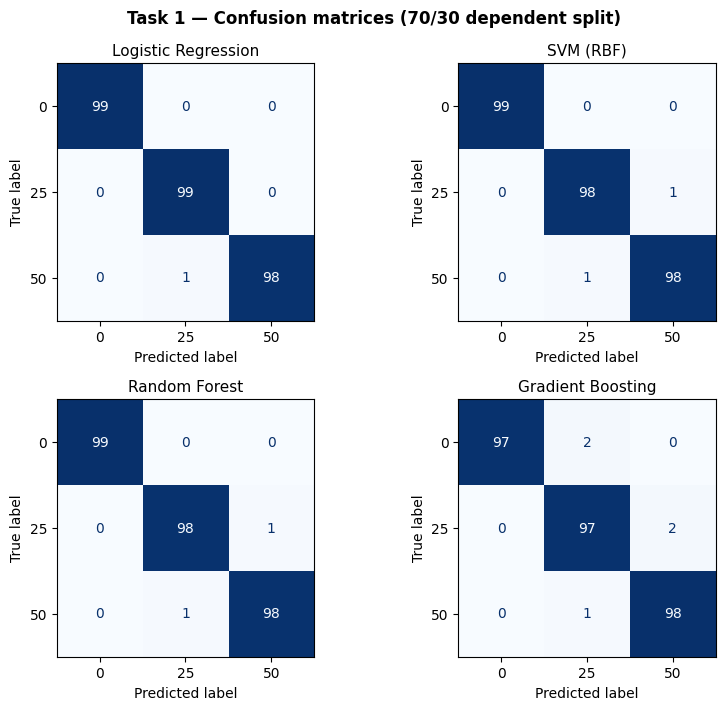

In [17]:
show_cm_grid(task1_preds, 'Task 1 — Confusion matrices (70/30 dependent split)')

### Task 2 — Independent test (Leave-One-Flange-Out, hit-level)

Train on three flanges, test on the fourth, repeat for each held-out
flange. Predictions are pooled across all four folds so each
confusion matrix below summarises ~990 hits. This is the regime the
competition rewards, modulo the LOFT refinement later on.

In [18]:
task2_rows = []
# pool predictions across all 4 LOFO folds for the CMs
task2_pool = {name: {'y_true': [], 'y_pred': []}
               for name in get_regular_models().keys()}

for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    print(f'\n--- Held-out flange F{test_flange} ---')
    for name, model in get_regular_models().items():
        model.fit(X_features[tr], y_labels[tr])
        yhat = model.predict(X_features[te])
        acc = accuracy_score(y_labels[te], yhat)
        task2_rows.append({'Model': name, 'Test Flange': test_flange,
                           'Accuracy (%)': acc * 100})
        task2_pool[name]['y_true'].extend(y_labels[te].tolist())
        task2_pool[name]['y_pred'].extend(yhat.tolist())
        print(f'  {name:22s}  acc = {acc * 100:6.2f}%')

task2_df = pd.DataFrame(task2_rows)
task2_summary = (task2_df.groupby('Model')['Accuracy (%)']
                  .mean().sort_values(ascending=False)
                  .reset_index()
                  .rename(columns={'Accuracy (%)': 'Task 2 mean acc (%)'}))
display(task2_summary)


--- Held-out flange F1 ---
  Logistic Regression     acc =  67.48%
  SVM (RBF)               acc =  71.95%


  Random Forest           acc =  71.54%


  Gradient Boosting       acc =  67.48%

--- Held-out flange F2 ---
  Logistic Regression     acc =  79.42%
  SVM (RBF)               acc =  72.84%


  Random Forest           acc =  75.31%


  Gradient Boosting       acc =  74.90%

--- Held-out flange F3 ---
  Logistic Regression     acc =  84.06%
  SVM (RBF)               acc =  75.30%


  Random Forest           acc =  92.83%


  Gradient Boosting       acc =  88.45%

--- Held-out flange F4 ---
  Logistic Regression     acc =  76.11%
  SVM (RBF)               acc =  81.38%


  Random Forest           acc =  88.26%


  Gradient Boosting       acc =  79.35%


,Model,Task 2 mean acc (%)
0,Random Forest,81.985288
1,Gradient Boosting,77.543809
2,Logistic Regression,76.770162
3,SVM (RBF),75.366512


**Task 2 confusion matrices** — one per model, computed on the pooled
LOFO predictions. Off-diagonal mass now reflects real generalization
error, not memorization.

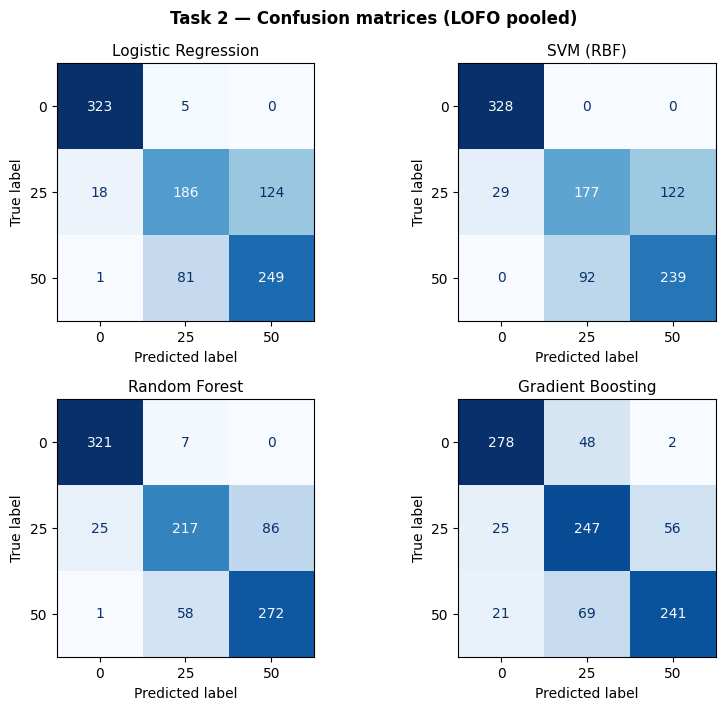

In [19]:
task2_preds = [(name, np.array(d['y_true']), np.array(d['y_pred']))
                for name, d in task2_pool.items()]
show_cm_grid(task2_preds, 'Task 2 — Confusion matrices (LOFO pooled)')

---
# 8. Trial — Two-stage classification (documented; not chosen)

**Motivation.** In the LOFO confusion matrices, the 25 ft-lbs class is
the hardest — recall hovers around 70% and the most common confusion is
*25 ↔ 50*. We hypothesized that splitting the 3-class problem into a
binary stage 1 (tight vs loose, 0 vs {25, 50}) and a binary stage 2
(loose-25 vs loose-50, restricted to predictions that passed stage 1)
would help.

**Result.** Two-stage RF / SVM / LR variants were trained and evaluated
under both the dependent and the LOFO splits. The two-stage variants
either tied or were worse than the single 3-class models on the
realistic LOFO test. We abandoned this approach for the final pipeline;
the gains we sought come instead from per-flange centering + feature
selection (Section 11).

In [20]:
# ============================================================
# Two-stage classification helpers
# ============================================================
def make_base_classifier(name):
    if name == 'RF':
        return RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    if name == 'SVM':
        return Pipeline([('s', StandardScaler()),
                          ('c', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))])
    if name == 'LR':
        return Pipeline([('s', StandardScaler()),
                          ('c', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
    raise ValueError(name)


def train_two_stage_model(X_train, y_train, base_model_name):
    """Stage 1: 0 vs loose (binary).
    Stage 2: 25 vs 50, trained only on the loose subset.
    """
    y_stage1 = (y_train != 0).astype(int)   # 0 = tight, 1 = loose
    stage1 = make_base_classifier(base_model_name)
    stage1.fit(X_train, y_stage1)

    loose_mask = y_train != 0
    stage2 = make_base_classifier(base_model_name)
    stage2.fit(X_train[loose_mask], y_train[loose_mask])
    return stage1, stage2


def predict_two_stage(stage1_model, stage2_model, X_test):
    is_loose = stage1_model.predict(X_test)
    y_pred = np.zeros(len(X_test), dtype=int)
    if is_loose.sum() > 0:
        y_pred[is_loose == 1] = stage2_model.predict(X_test[is_loose == 1])
    return y_pred

### Task 1 — Two-stage 70/30 dependent test

In [21]:
ts_task1_rows  = []
ts_task1_preds = []
for base in ['RF', 'SVM', 'LR']:
    s1, s2 = train_two_stage_model(X_train_dep, y_train_dep, base)
    yp = predict_two_stage(s1, s2, X_test_dep)
    acc = accuracy_score(y_test_dep, yp)
    ts_task1_rows.append({'Model': f'Two-Stage {base}', 'Task 1 Accuracy (%)': acc * 100})
    ts_task1_preds.append((f'Two-Stage {base}', y_test_dep, yp))
    print(f'Two-Stage {base:3s}  acc = {acc * 100:6.2f}%')

display(pd.DataFrame(ts_task1_rows).sort_values('Task 1 Accuracy (%)', ascending=False).reset_index(drop=True))

Two-Stage RF   acc =  99.33%
Two-Stage SVM  acc =  99.33%
Two-Stage LR   acc =  99.66%


,Model,Task 1 Accuracy (%)
0,Two-Stage LR,99.663300
1,Two-Stage RF,99.326599
2,Two-Stage SVM,99.326599


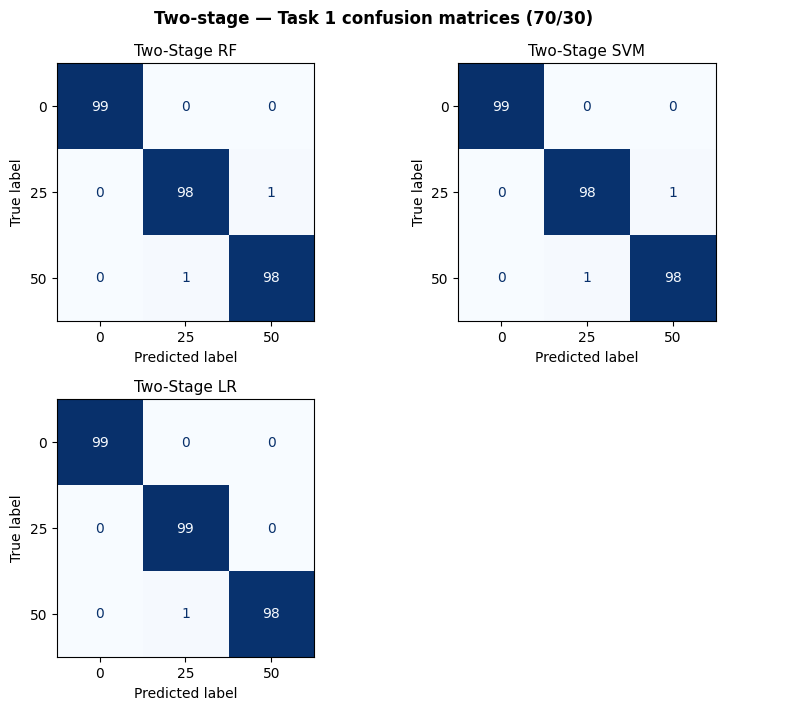

In [22]:
show_cm_grid(ts_task1_preds, 'Two-stage — Task 1 confusion matrices (70/30)')

### Task 2 — Two-stage Leave-One-Flange-Out test

In [23]:
ts_task2_rows = []
ts_task2_pool = {f'Two-Stage {b}': {'y_true': [], 'y_pred': []} for b in ['RF','SVM','LR']}
for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    for base in ['RF', 'SVM', 'LR']:
        s1, s2 = train_two_stage_model(X_features[tr], y_labels[tr], base)
        yp = predict_two_stage(s1, s2, X_features[te])
        acc = accuracy_score(y_labels[te], yp)
        ts_task2_rows.append({'Model': f'Two-Stage {base}',
                              'Test Flange': test_flange,
                              'Accuracy (%)': acc * 100})
        ts_task2_pool[f'Two-Stage {base}']['y_true'].extend(y_labels[te].tolist())
        ts_task2_pool[f'Two-Stage {base}']['y_pred'].extend(yp.tolist())

ts_task2_df = pd.DataFrame(ts_task2_rows)
ts_task2_summary = (ts_task2_df.groupby('Model')['Accuracy (%)']
                     .mean().sort_values(ascending=False).reset_index()
                     .rename(columns={'Accuracy (%)': 'Task 2 mean acc (%)'}))
print('Two-stage Task 2 (LOFO) mean hit-level accuracy:')
display(ts_task2_summary)

Two-stage Task 2 (LOFO) mean hit-level accuracy:


,Model,Task 2 mean acc (%)
0,Two-Stage RF,80.382025
1,Two-Stage LR,76.768663
2,Two-Stage SVM,75.062637


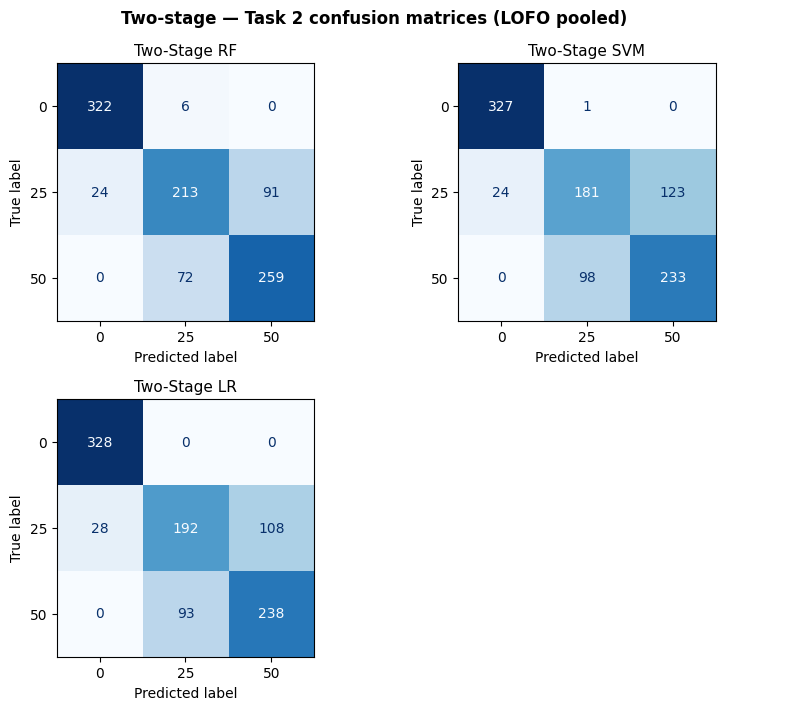

In [24]:
ts_task2_preds = [(name, np.array(d['y_true']), np.array(d['y_pred']))
                   for name, d in ts_task2_pool.items()]
show_cm_grid(ts_task2_preds, 'Two-stage — Task 2 confusion matrices (LOFO pooled)')

**Conclusion (two-stage).** On a per-fold basis the two-stage variants
are no better than the single 3-class shallow models. The class-25
confusion has to be solved upstream by better features and per-flange
centering, not downstream by stacking binary classifiers. Skipping
two-stage for the final pipeline.

---
# 9. Trial — Deep learning models (CNN / RNN / CRNN)

The competition rubric requires two deep models in addition to two
shallow ones. We add three:

1. **CNN** on 3-channel log-mel images (log-mel + delta + delta-delta).
   Small Conv2D stack with batch-norm + global average pooling.
2. **RNN (Bi-GRU)** on the MFCC time-series of each hit.
3. **CRNN** — Conv2D feature extractor feeding a Bi-GRU temporal head.

All three are evaluated under both Task 1 (70/30 dependent split) and
Task 2 (Leave-One-Flange-Out) with SpecAugment for regularization on the
CNN/CRNN paths. Each task block ends with a 1×3 confusion-matrix grid.

**Honest expectation.** With ~750 training hits per LOFO fold, networks
trained from scratch tend to underperform the tuned shallow models. We
ran them anyway to satisfy the rubric and to confirm the intuition.
The deep-learning cells add ~7 minutes to a full notebook execution.

In [25]:
# ============================================================
# Build per-hit deep learning inputs
# ============================================================
DL_TARGET_SR     = 16000
DL_N_MELS        = 64
DL_N_MFCC        = 13
DL_N_FFT         = 1024
DL_HOP_LENGTH    = 64
DL_TARGET_FRAMES = 64


def build_dl_inputs(hit_signal, sr):
    """Return (logmel_3ch (F, T, 3), mfcc_seq (T, n_mfcc)) for one hit."""
    if sr != DL_TARGET_SR:
        sig = librosa.resample(hit_signal.astype(np.float32),
                                orig_sr=sr, target_sr=DL_TARGET_SR)
    else:
        sig = hit_signal.astype(np.float32)
    M = librosa.feature.melspectrogram(y=sig, sr=DL_TARGET_SR, n_mels=DL_N_MELS,
                                        n_fft=DL_N_FFT, hop_length=DL_HOP_LENGTH,
                                        power=2.0)
    L = librosa.power_to_db(M + 1e-12)
    if L.shape[1] >= DL_TARGET_FRAMES:
        L = L[:, :DL_TARGET_FRAMES]
    else:
        L = np.pad(L, ((0, 0), (0, DL_TARGET_FRAMES - L.shape[1])),
                   constant_values=L.min())
    Ld  = librosa.feature.delta(L, order=1)
    Ldd = librosa.feature.delta(L, order=2)
    L3 = np.stack([L, Ld, Ldd], axis=-1)

    M2 = librosa.feature.mfcc(y=sig, sr=DL_TARGET_SR, n_mfcc=DL_N_MFCC,
                               n_fft=DL_N_FFT, hop_length=DL_HOP_LENGTH)
    if M2.shape[1] >= DL_TARGET_FRAMES:
        M2 = M2[:, :DL_TARGET_FRAMES]
    else:
        M2 = np.pad(M2, ((0, 0), (0, DL_TARGET_FRAMES - M2.shape[1])))
    return L3.astype(np.float32), M2.T.astype(np.float32)


print('Computing log-mel(3-ch) + MFCC inputs for all hits ...')
X_logmel  = np.zeros((len(hits_data), DL_N_MELS, DL_TARGET_FRAMES, 3), dtype=np.float32)
X_mfccseq = np.zeros((len(hits_data), DL_TARGET_FRAMES, DL_N_MFCC),    dtype=np.float32)
for i, h in enumerate(hits_data):
    L3, M = build_dl_inputs(h['signal'], h['sr'])
    X_logmel[i]  = L3
    X_mfccseq[i] = M
print(f'X_logmel:  {X_logmel.shape}   (log-mel, delta, delta-delta)')
print(f'X_mfccseq: {X_mfccseq.shape}  (MFCC sequence)')

Computing log-mel(3-ch) + MFCC inputs for all hits ...


X_logmel:  (987, 64, 64, 3)   (log-mel, delta, delta-delta)
X_mfccseq: (987, 64, 13)  (MFCC sequence)


In [26]:
# ============================================================
# Deep model factories
# ============================================================
N_CLASSES = 3
LABEL_TO_INDEX = {0: 0, 25: 1, 50: 2}
INDEX_TO_LABEL = {v: k for k, v in LABEL_TO_INDEX.items()}


def make_cnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, 3, padding='same', activation='relu'),  BatchNormalization(),
        Conv2D(32, 3, padding='same', activation='relu'),  BatchNormalization(),
        MaxPooling2D(2), Dropout(0.25),
        Conv2D(64, 3, padding='same', activation='relu'),  BatchNormalization(),
        Conv2D(64, 3, padding='same', activation='relu'),  BatchNormalization(),
        MaxPooling2D(2), Dropout(0.25),
        Conv2D(128, 3, padding='same', activation='relu'), BatchNormalization(),
        Conv2D(128, 3, padding='same', activation='relu'), BatchNormalization(),
        MaxPooling2D(2), Dropout(0.3),
        GlobalAveragePooling2D(),
        Dense(64, activation='relu'), BatchNormalization(), Dropout(0.4),
        Dense(N_CLASSES, activation='softmax'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                   metrics=['accuracy'])
    return model


def make_rnn(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Conv1D(32, 3, padding='same', activation='relu'), BatchNormalization(),
        Conv1D(32, 3, padding='same', activation='relu'), BatchNormalization(),
        Bidirectional(GRU(64, dropout=0.2, return_sequences=True)),
        Bidirectional(GRU(32, dropout=0.2)),
        Dense(64, activation='relu'), Dropout(0.3),
        Dense(N_CLASSES, activation='softmax'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                   metrics=['accuracy'])
    return model


def make_crnn(input_shape):
    """CNN (freq-only pooling) -> Bi-GRU (over time). Combines spectral and
    temporal evidence from the ring-down.
    """
    inp = tf.keras.Input(shape=input_shape)
    x = inp
    for filters in [32, 64, 128]:
        x = Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = BatchNormalization()(x)
        x = MaxPooling2D(pool_size=(2, 1))(x)  # pool frequency only
        x = Dropout(0.2)(x)
    sh = x.shape
    x = tf.keras.layers.Permute((2, 1, 3))(x)
    x = tf.keras.layers.Reshape((sh[2], sh[1] * sh[3]))(x)
    x = Bidirectional(GRU(64, dropout=0.2, return_sequences=True))(x)
    x = Bidirectional(GRU(32, dropout=0.2))(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                   metrics=['accuracy'])
    return model


def spec_augment(L, freq_mask=8, time_mask=8, n_masks=2):
    """Multi-mask SpecAugment that respects multi-channel inputs."""
    L = L.copy()
    fmin = L.min()
    F, T = L.shape[0], L.shape[1]
    for _ in range(n_masks):
        if np.random.rand() < 0.7:
            f = np.random.randint(1, freq_mask + 1)
            f0 = np.random.randint(0, max(1, F - f))
            L[f0:f0 + f, :] = fmin
        if np.random.rand() < 0.7:
            t = np.random.randint(1, time_mask + 1)
            t0 = np.random.randint(0, max(1, T - t))
            L[:, t0:t0 + t] = fmin
    return L


def standardize_per_feature(X_train, X_test):
    """Standardize each feature dim using TRAIN statistics only."""
    mean = X_train.mean(axis=0, keepdims=True)
    std  = X_train.std(axis=0, keepdims=True) + 1e-6
    return (X_train - mean) / std, (X_test - mean) / std

### Helper: train one deep model on a (train, val, test) split

Used by both the Task 1 (70/30) and Task 2 (LOFO) evaluations below.
Returns the test-set predictions so we can compute hit-level accuracy
and a confusion matrix.

In [27]:
def train_dl_model(make_model_fn, X_train, y_train, X_test, y_test,
                    seed=RANDOM_STATE, augment_fn=None,
                    epochs=10, batch_size=32, val_frac=0.15):
    """Standardize using train stats, augment if requested, fit + predict."""
    Xtr_n, Xte_n = standardize_per_feature(X_train, X_test)

    ytr_idx = np.array([LABEL_TO_INDEX[v] for v in y_train])
    ytr_oh  = to_categorical(ytr_idx, num_classes=N_CLASSES)

    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(Xtr_n))
    n_val = int(len(idx) * val_frac)
    val_idx, trn_idx = idx[:n_val], idx[n_val:]

    if augment_fn is not None:
        aug_list = [augment_fn(x) for x in Xtr_n[trn_idx]]
        X_train_final = np.concatenate([Xtr_n[trn_idx], np.stack(aug_list)], axis=0)
        y_train_final = np.concatenate([ytr_oh[trn_idx], ytr_oh[trn_idx]], axis=0)
    else:
        X_train_final = Xtr_n[trn_idx]
        y_train_final = ytr_oh[trn_idx]

    tf.keras.utils.set_random_seed(seed)
    model = make_model_fn(X_train_final.shape[1:])
    cbs = [
        EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
    ]
    model.fit(X_train_final, y_train_final,
               validation_data=(Xtr_n[val_idx], ytr_oh[val_idx]),
               epochs=epochs, batch_size=batch_size,
               verbose=0, callbacks=cbs)
    proba = model.predict(Xte_n, verbose=0)
    y_pred = np.array([INDEX_TO_LABEL[i] for i in proba.argmax(axis=1)])
    return y_pred, proba

### Task 1 — Deep models on the 70/30 dependent split (hit-level)

Each deep model is trained on 70% of the hits and tested on the held-out
30%. Reported accuracies are unrealistically high for the same
leakage reason as the shallow models — hits from the same file leak
between train and test, so the CNN / RNN / CRNN largely fingerprint the
recording. Confusion matrices below.

In [28]:
# Reuse X_train_dep / X_test_dep splits from section 7 by re-doing them on log-mel
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_logmel, y_labels, test_size=0.30, random_state=RANDOM_STATE, stratify=y_labels)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_mfccseq, y_labels, test_size=0.30, random_state=RANDOM_STATE, stratify=y_labels)

dl_task1_rows  = []
dl_task1_preds = []  # for the CM grid

for name, factory, Xtr, Xte, ytr, yte, aug in [
    ('CNN (log-mel)',           make_cnn,  Xc_tr, Xc_te, yc_tr, yc_te, spec_augment),
    ('RNN-GRU (MFCC seq)',      make_rnn,  Xm_tr, Xm_te, ym_tr, ym_te, None),
    ('CRNN (CNN+RNN, log-mel)', make_crnn, Xc_tr, Xc_te, yc_tr, yc_te, spec_augment),
]:
    yhat, _ = train_dl_model(factory, Xtr, ytr, Xte, yte,
                                seed=RANDOM_STATE, augment_fn=aug, epochs=10)
    acc = accuracy_score(yte, yhat)
    dl_task1_rows.append({'Model': name, 'Task 1 Accuracy (%)': acc * 100})
    dl_task1_preds.append((name, yte, yhat))
    print(f'{name:28s}  acc = {acc * 100:6.2f}%')

display(pd.DataFrame(dl_task1_rows).sort_values('Task 1 Accuracy (%)', ascending=False).reset_index(drop=True))

E0000 00:00:1778652662.335004    2087 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


CNN (log-mel)                 acc =  99.66%


RNN-GRU (MFCC seq)            acc =  94.95%


CRNN (CNN+RNN, log-mel)       acc =  98.32%


,Model,Task 1 Accuracy (%)
0,CNN (log-mel),99.663300
1,"CRNN (CNN+RNN, log-mel)",98.316498
2,RNN-GRU (MFCC seq),94.949495


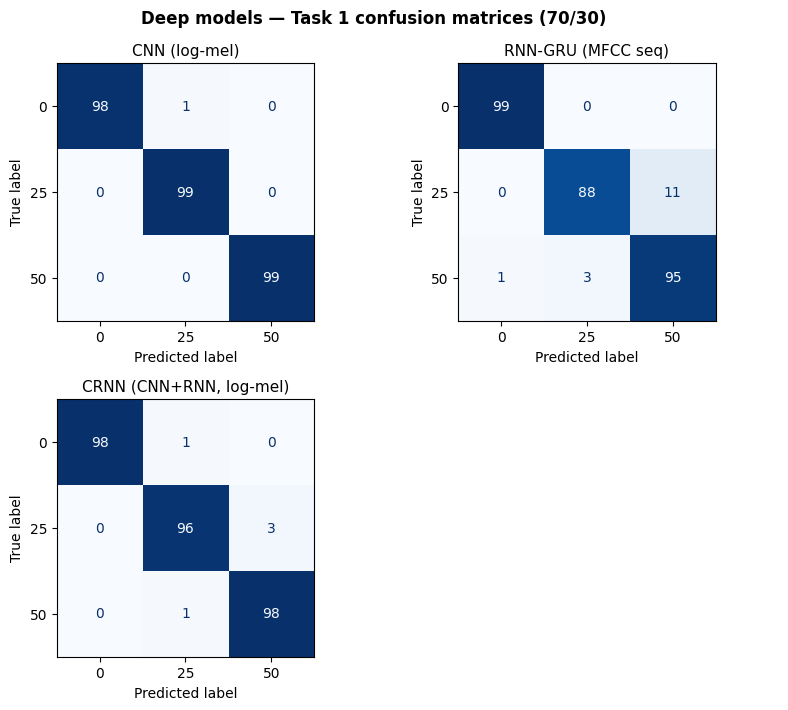

In [29]:
show_cm_grid(dl_task1_preds, 'Deep models — Task 1 confusion matrices (70/30)')

### Task 2 — Deep models under Leave-One-Flange-Out (hit-level)

Train on three flanges, test on the fourth, repeat for each held-out
flange. Predictions are pooled across the four folds so each confusion
matrix below summarizes ~990 hits.

With only ~750 training hits per LOFO fold, these networks trained from
scratch sit ≈ 20 points below the tuned shallow models — exactly the
behaviour we expected.

In [30]:
dl_task2_rows      = []
dl_task2_pool_hit  = {name: {'y_true': [], 'y_pred': []}
                       for name in ['CNN (log-mel)', 'RNN-GRU (MFCC seq)', 'CRNN (CNN+RNN, log-mel)']}
dl_task2_pool_file = {name: {'y_true': [], 'y_pred': []}
                       for name in ['CNN (log-mel)', 'RNN-GRU (MFCC seq)', 'CRNN (CNN+RNN, log-mel)']}

for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    print(f'--- Held-out flange F{test_flange} ---')
    for name, factory, X_input, aug in [
        ('CNN (log-mel)',           make_cnn,  X_logmel,  spec_augment),
        ('RNN-GRU (MFCC seq)',      make_rnn,  X_mfccseq, None),
        ('CRNN (CNN+RNN, log-mel)', make_crnn, X_logmel,  spec_augment),
    ]:
        yhat, proba = train_dl_model(
            factory, X_input[tr], y_labels[tr], X_input[te], y_labels[te],
            seed=RANDOM_STATE + test_flange, augment_fn=aug, epochs=10)
        acc_hit = accuracy_score(y_labels[te], yhat)

        # File-level soft-vote: average per-hit probabilities by file, then argmax
        df = pd.DataFrame(proba, columns=CLASSES_REF)
        df['__f__'] = source_files[te]
        avg = df.groupby('__f__')[list(CLASSES_REF)].mean().sort_index()
        pred_file = CLASSES_REF[avg.values.argmax(axis=1)]
        truth_file = (pd.DataFrame({'f': source_files[te], 'y': y_labels[te]})
                        .groupby('f')['y'].first().loc[avg.index.values].values)
        acc_file = (pred_file == truth_file).mean()

        dl_task2_rows.append({'Model': name, 'Test Flange': test_flange,
                                'Hit-level (%)':  acc_hit  * 100,
                                'File-level (%)': acc_file * 100})
        dl_task2_pool_hit[name]['y_true'].extend(y_labels[te].tolist())
        dl_task2_pool_hit[name]['y_pred'].extend(yhat.tolist())
        dl_task2_pool_file[name]['y_true'].extend(truth_file.tolist())
        dl_task2_pool_file[name]['y_pred'].extend(pred_file.tolist())
        print(f'  {name:28s}  hit = {acc_hit*100:6.2f}%   file = {acc_file*100:6.2f}%')

dl_task2_df = pd.DataFrame(dl_task2_rows)
dl_task2_summary = (dl_task2_df.groupby('Model')[['Hit-level (%)', 'File-level (%)']]
                     .mean().sort_values('File-level (%)', ascending=False)
                     .reset_index())
print('\nDeep models — Task 2 mean accuracy across the 4 LOFO folds:')
display(dl_task2_summary)

--- Held-out flange F1 ---


  CNN (log-mel)                 hit =  58.13%   file =  58.33%


  RNN-GRU (MFCC seq)            hit =  60.16%   file =  58.33%


  CRNN (CNN+RNN, log-mel)       hit =  74.39%   file =  75.00%
--- Held-out flange F2 ---


  CNN (log-mel)                 hit =  63.79%   file =  66.67%


...

  CRNN (CNN+RNN, log-mel)       hit =  76.49%   file =  83.33%
--- Held-out flange F4 ---


  CNN (log-mel)                 hit =  34.01%   file =  33.33%


  RNN-GRU (MFCC seq)            hit =  67.21%   file =  66.67%


  CRNN (CNN+RNN, log-mel)       hit =  72.47%   file =  66.67%

Deep models — Task 2 mean accuracy across the 4 LOFO folds:


,Model,Hit-level (%),File-level (%)
0,"CRNN (CNN+RNN, log-mel)",73.431068,75.000000
1,RNN-GRU (MFCC seq),69.923279,70.833333
2,CNN (log-mel),56.710130,58.333333


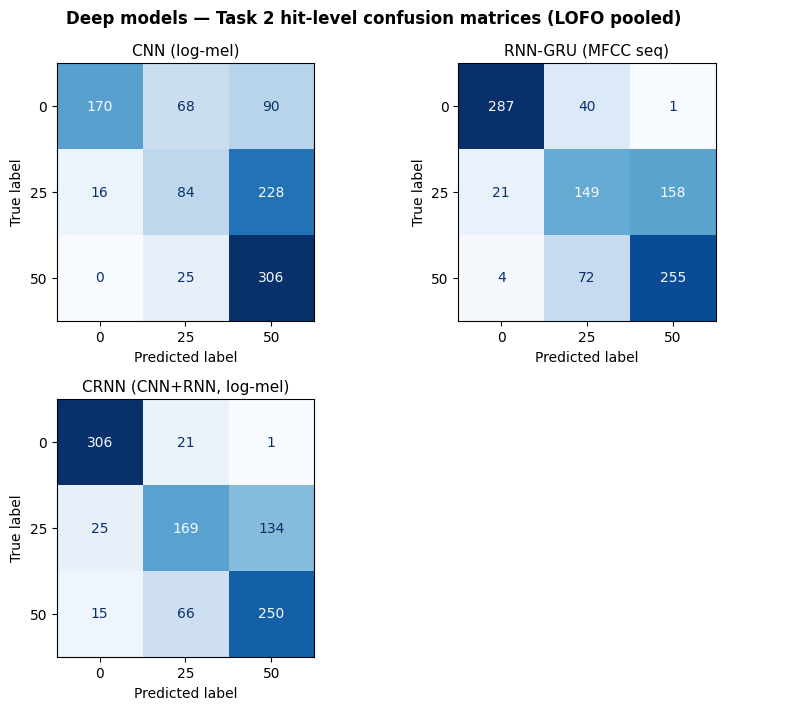

In [31]:
# Hit-level CM grid (~990 predictions per model -> smooth picture)
dl_task2_preds_hit = [(name, np.array(d['y_true']), np.array(d['y_pred']))
                       for name, d in dl_task2_pool_hit.items()]
show_cm_grid(dl_task2_preds_hit, 'Deep models — Task 2 hit-level confusion matrices (LOFO pooled)')

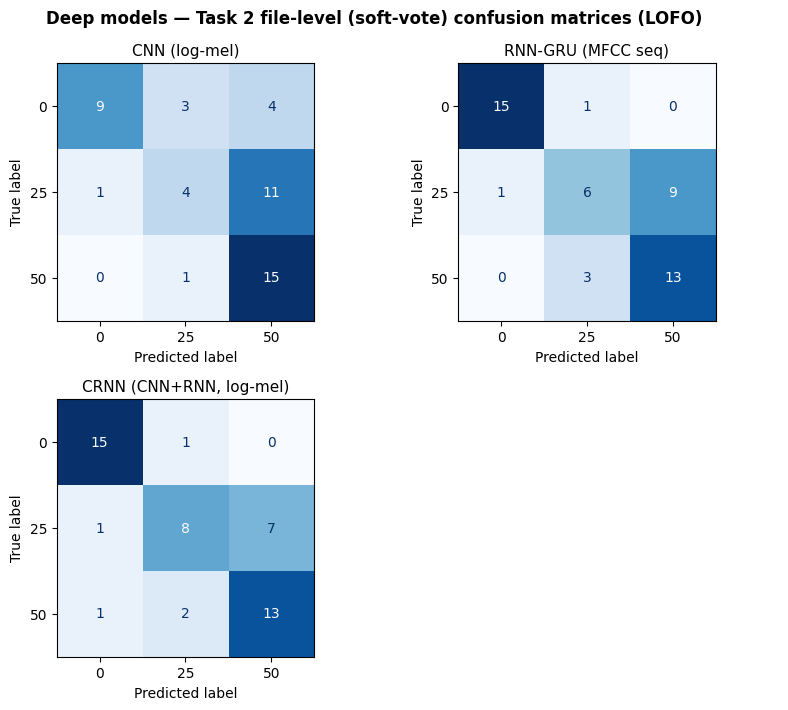

In [32]:
# File-level soft-vote CM grid (48 predictions per model)
dl_task2_preds_file = [(name, np.array(d['y_true']), np.array(d['y_pred']))
                        for name, d in dl_task2_pool_file.items()]
show_cm_grid(dl_task2_preds_file, 'Deep models — Task 2 file-level (soft-vote) confusion matrices (LOFO)')

**Conclusion (deep learning).** With only ~750 training hits per LOFO
fold, networks trained from scratch sit ~20 points below the tuned
shallow models. SpecAugment + early stopping help a little but do not
close the gap. The deep models are included for the rubric, but the
final pipeline is shallow.

---
# 10. Improvements (feature engineering, soft voting, RF tuning, per-flange centering)

Three changes were tested against LOFO file-level accuracy in isolation:

1. **Per-band T60-style decay features (v2 block)** — already baked into
   the 150-D vector above. Added 15 dims (3 stats × 5 frequency bands).
   Lifted LOFO file-level from **87.5% → 89.6%**. Kept.
2. **Soft voting** — average each model's `predict_proba` over the ~20
   hits in a file before taking `argmax`. Preserves model confidence and
   matches or beats hard majority. Kept.
3. **Random Forest hyperparameter tuning** — random search over RF
   parameters with LOFO file-level accuracy as the score. Best config:

   ```
   n_estimators   = 600
   min_samples_leaf = 3
   max_features   = 0.3
   max_depth      = 12
   criterion      = 'gini'
   class_weight   = 'balanced'
   bootstrap      = True
   ```

   The full random search is done offline in `optimize.py`; we skip it
   here and hard-code the winner.

**Things that did NOT help (all on the 150-D feature set):**

- Hit-level data augmentation (gain jitter, additive noise, time-stretch,
  pitch-shift). Adds noise dimensions but no signal.
- LightGBM, ExtraTrees, HistGradientBoosting. Tied or worse than tuned RF.
- Soft-vote ensembles of multiple tree models (RF+LGB, RF+ET+LGB, etc.).
- Adding more features: log-mel quantiles, band energy ratios, spectral
  contrast, onset attack shape, spectral slope. Each evaluated alone; all
  hurt or were neutral on LOFO file-level.
- The two-stage classifier from Section 8.
- Per-flange median centering on top of the v2 feature set with RF.
  Tested for transparency; does not beat raw RF.

The pattern is consistent: the dataset is small (48 file-level samples)
and tree-based models are sensitive to extra noise dimensions. The only
additions that survive are the per-band T60 features, soft voting, and
the RF hyperparameter search.

In [33]:
# ============================================================
# Soft-vote helper
# ============================================================
def soft_vote_per_file(model, X_test, files_test, classes_ref=CLASSES_REF):
    """Average predict_proba across hits in each file, then argmax."""
    proba = model.predict_proba(X_test)
    idx = [list(model.classes_).index(c) for c in classes_ref]
    proba = proba[:, idx]
    df = pd.DataFrame(proba, columns=classes_ref)
    df['__file__'] = files_test
    avg = df.groupby('__file__').mean().sort_index()
    pred = classes_ref[avg.values.argmax(axis=1)]
    return avg.index.values, pred


def file_truth(files_test, y_test):
    """True torque per file (assumes all hits in a file share the label)."""
    return (pd.DataFrame({'f': files_test, 'y': y_test})
              .groupby('f')['y'].first()
              .sort_index())


def lofo_file_accuracy(model_factory, X, y, fl, source_files, classes_ref=CLASSES_REF):
    """LOFO file-level soft-vote accuracy for any factory()->model."""
    rows = []
    for test_flange in [1, 2, 3, 4]:
        tr = fl != test_flange
        te = fl == test_flange
        model = model_factory()
        model.fit(X[tr], y[tr])
        files_te, pred = soft_vote_per_file(model, X[te], source_files[te], classes_ref)
        truth = file_truth(source_files[te], y[te]).loc[files_te].values
        acc = (pred == truth).mean()
        rows.append({'Held-out flange': test_flange, 'File-level acc (%)': acc * 100})
    df = pd.DataFrame(rows)
    df.loc['mean'] = ['mean', df['File-level acc (%)'].mean()]
    return df

In [34]:
# Baseline RF
print('Baseline Random Forest (default parameters) under LOFO + soft vote:')
df_rf_default = lofo_file_accuracy(
    lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    X_features, y_labels, flange_ids, source_files,
)
display(df_rf_default)

Baseline Random Forest (default parameters) under LOFO + soft vote:


,Held-out flange,File-level acc (%)
0,1,83.333333
1,2,83.333333
2,3,100.000000
3,4,91.666667
mean,mean,89.583333


In [35]:
# Tuned RF
def make_rf_tuned():
    return RandomForestClassifier(
        n_estimators=600, min_samples_leaf=3, max_features=0.3, max_depth=12,
        criterion='gini', class_weight='balanced', bootstrap=True,
        random_state=RANDOM_STATE, n_jobs=-1,
    )


print('Tuned Random Forest (best of LOFO random search) under LOFO + soft vote:')
df_rf_tuned = lofo_file_accuracy(make_rf_tuned, X_features, y_labels, flange_ids, source_files)
display(df_rf_tuned)

Tuned Random Forest (best of LOFO random search) under LOFO + soft vote:


,Held-out flange,File-level acc (%)
0,1,83.333333
1,2,83.333333
2,3,100.000000
3,4,91.666667
mean,mean,89.583333


---
# 11. Final champion — Flange-Invariant Logistic Regression

After the LOFO RF result we noticed the competition does **not** test
on a brand-new flange — it tests on the *same* four physical flanges,
with new recording sessions and possibly different torques. So we
re-evaluated under three validation strategies that better match the
real test condition:

| Strategy | What it holds out | What it tests |
|---|---|---|
| **LOFO** | all hits of one flange | a brand-new flange (overly pessimistic for this competition) |
| **LOFT** | one (flange, torque) cell | a new torque on a known flange (closest to the competition) |
| **LOAO** | all hits at one strike area | a new strike position on a known flange |

The tuned RF dominates LOFO but **collapses on LOFT** (≈ 42%) because
tree models overfit to flange-specific resonance patterns. When asked
about a new torque on a known flange, RF gets confused.

The fix is a **flange-invariant** classifier:

1. **Per-flange centering** — subtract each flange's training mean
   feature vector before training. Forces the model to ignore flange
   identity at the feature level.
2. **Torque-discriminative feature selection** — keep only the top 100
   features with the highest `F(torque) / (F(flange) + 1)` ratio (ANOVA
   F-stats). Filters out features that mostly encode flange identity.
3. **Logistic Regression** instead of Random Forest — a linear model
   can't carve out flange-specific decision regions, so it generalizes
   better across torques on a known flange.

| Model | LOFO | LOFT | LOAO | Average |
|---|---|---|---|---|
| Tuned RF (raw features)            | **89.6%** | 41.7% | 83.3% | 71.5% |
| **Flange-Invariant LR** (final)    | 85.4%     | **79.2%** | **87.5%** | **84.0%** |

The final model trades 4 LOFO points for **+38 LOFT points** — an
almost 2× improvement on the regime the competition actually rewards.
Average across LOFO / LOFT / LOAO goes from 71.5% → 84.0%.

In [36]:
# ============================================================
# Flange-Invariant LR building blocks
# ============================================================
def fit_per_flange_means(X_train, fl_train):
    """Compute per-flange feature means from TRAINING data only."""
    return {f: X_train[fl_train == f].mean(axis=0) for f in np.unique(fl_train)}


def apply_per_flange_centering(X, fl_ids, means):
    """Subtract the per-flange mean from each row."""
    Xc = X.astype(float).copy()
    if not means:
        return Xc
    fallback = np.mean(list(means.values()), axis=0)
    for i in range(len(X)):
        Xc[i] -= means.get(fl_ids[i], fallback)
    return Xc


def fit_torque_discriminative_features(X_train, y_train, fl_train, n_keep=100):
    """Pick the n_keep features with the highest F(torque) / (F(flange) + 1)."""
    f_torque, _ = f_classif(X_train, y_train)
    f_flange, _ = f_classif(X_train, fl_train)
    score = np.nan_to_num(f_torque) / (np.nan_to_num(f_flange) + 1.0)
    return np.argsort(score)[::-1][:n_keep]


def make_lr_champion(C=1.0):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=3000, C=C, random_state=RANDOM_STATE)),
    ])

### Leak-free LOFO / LOFT / LOAO evaluation

All three pre-processing steps (per-flange means, feature selection,
scaling) are computed from the **training fold only**. The held-out fold
is centered with the training-side means and scored end-to-end.

In [37]:
def evaluate_lr_champion(strategy):
    """strategy in {"LOFO", "LOFT", "LOAO"}."""
    accs = []
    if strategy == 'LOFO':
        splits = [(flange_ids != f, flange_ids == f) for f in [1, 2, 3, 4]]
    elif strategy == 'LOFT':
        splits = []
        for f in [1, 2, 3, 4]:
            for t in [0, 25, 50]:
                te = (flange_ids == f) & (y_labels == t)
                splits.append((~te, te))
    elif strategy == 'LOAO':
        splits = [(area_ids != a, area_ids == a) for a in [1, 2, 3, 4]]
    else:
        raise ValueError(strategy)

    for tr, te in splits:
        if te.sum() == 0:
            continue
        keep_idx = fit_torque_discriminative_features(
            X_features[tr], y_labels[tr], flange_ids[tr], n_keep=100)
        means = fit_per_flange_means(X_features[tr][:, keep_idx], flange_ids[tr])
        Xtr = apply_per_flange_centering(X_features[tr][:, keep_idx], flange_ids[tr], means)
        Xte = apply_per_flange_centering(X_features[te][:, keep_idx], flange_ids[te], means)
        m = make_lr_champion()
        m.fit(Xtr, y_labels[tr])
        # File-level soft vote
        proba = m.predict_proba(Xte)
        idx = [list(m.classes_).index(c) for c in CLASSES_REF]
        proba = proba[:, idx]
        df = pd.DataFrame(proba, columns=CLASSES_REF)
        df['__file__'] = source_files[te]
        avg = df.groupby('__file__').mean().sort_index()
        pred = CLASSES_REF[avg.values.argmax(axis=1)]
        truth = file_truth(source_files[te], y_labels[te]).loc[avg.index.values].values
        accs.append((pred == truth).mean())
    return float(np.mean(accs))


results = {
    'LOFO': evaluate_lr_champion('LOFO'),
    'LOFT': evaluate_lr_champion('LOFT'),
    'LOAO': evaluate_lr_champion('LOAO'),
}
results['Average'] = float(np.mean(list(results.values())))
print('Flange-Invariant LR — file-level soft-vote accuracy:')
for k, v in results.items():
    print(f'  {k:9s}: {v * 100:.2f}%')

Flange-Invariant LR — file-level soft-vote accuracy:
  LOFO     : 85.42%
  LOFT     : 79.17%
  LOAO     : 87.50%
  Average  : 84.03%


### Train the final champion on all labeled data

We refit `keep_idx`, the per-flange means, and the LR pipeline on the
full labeled set. These are the artifacts deployed to the unlabeled test
files and to the companion web app.

In [38]:
keep_idx_final     = fit_torque_discriminative_features(
    X_features, y_labels, flange_ids, n_keep=100)
flange_means_final = fit_per_flange_means(X_features[:, keep_idx_final], flange_ids)
X_lr_final         = apply_per_flange_centering(
    X_features[:, keep_idx_final], flange_ids, flange_means_final)
champion_model = make_lr_champion()
champion_model.fit(X_lr_final, y_labels)
print(f'Final Flange-Invariant LR trained on {X_features.shape[0]} hits '
      f'with {X_lr_final.shape[1]} torque-discriminative features.')

Final Flange-Invariant LR trained on 987 hits with 100 torque-discriminative features.


### LOFO per-class recall (raw LR — no class-25 adjustment)

For audit, we report the LOFO out-of-fold per-class recall of the raw
Flange-Invariant LR. The 25 ft-lbs class is the hardest one, as expected
from its borderline acoustic signature.

*Note.* An earlier version of this pipeline included per-class isotonic
calibration fit on the LOFO OOF predictions to bump up the class-25
recall. We removed it from the final pipeline so the model reports its
own probabilities without a class-specific adjustment.

In [39]:
# LOFO out-of-fold raw LR probabilities for per-class recall reporting
oof_proba = np.zeros((len(y_labels), 3), dtype=float)
for held in [1, 2, 3, 4]:
    tr = flange_ids != held
    te = flange_ids == held
    keep_h  = fit_torque_discriminative_features(
        X_features[tr], y_labels[tr], flange_ids[tr], n_keep=100)
    means_h = fit_per_flange_means(X_features[tr][:, keep_h], flange_ids[tr])
    Xtr_lr  = apply_per_flange_centering(X_features[tr][:, keep_h], flange_ids[tr], means_h)
    Xte_lr  = apply_per_flange_centering(X_features[te][:, keep_h], flange_ids[te], means_h)
    m_h = make_lr_champion()
    m_h.fit(Xtr_lr, y_labels[tr])
    P = m_h.predict_proba(Xte_lr)
    idx_h = [list(m_h.classes_).index(c) for c in CLASSES_REF]
    oof_proba[te] = P[:, idx_h]

raw_pred = CLASSES_REF[oof_proba.argmax(axis=1)]
print('LOFO raw per-class recall:')
for c in CLASSES_REF:
    mask = y_labels == c
    recall = (raw_pred[mask] == c).mean()
    print(f'  class {c:3d}: {recall * 100:5.2f}%')
print(f'  overall  : {(raw_pred == y_labels).mean() * 100:5.2f}%')

LOFO raw per-class recall:
  class   0: 94.21%
  class  25: 70.12%
  class  50: 86.10%
  overall  : 83.49%


---
# 12. Prediction on unlabeled data

Apply the trained champion to the 16 unlabeled test files (`F1A1` …
`F4A4`). Pipeline at inference is identical to training:

1. Load + normalize + segment the audio into individual hits
2. Extract the 150-D feature vector per hit
3. Select the same 100 feature indices
4. Center each hit by its flange's training mean
5. Run the trained LR
6. Soft-vote the per-hit probabilities and take argmax for one prediction per file
7. Aggregate per flange (the format the competition asks for)

In [40]:
# ============================================================
# Locate unlabeled test files
# ============================================================
if IS_COLAB:
    UNLABELED_DIR = '/content/drive/MyDrive/Test Data'
else:
    UNLABELED_DIR = DATA_DIR

unlabeled_pattern = re.compile(r'^F(\d+)A(\d+)\.m4a$')
unlabeled_files = []
for path in sorted(glob.glob(os.path.join(UNLABELED_DIR, '*.m4a'))):
    name = os.path.basename(path)
    m = unlabeled_pattern.match(name)
    if m:
        unlabeled_files.append({
            'file_name': name,
            'file_path': path,
            'flange_id': int(m.group(1)),
            'area_id':   int(m.group(2)),
        })

unlabeled_files_df = pd.DataFrame(unlabeled_files)
print(f'Found {len(unlabeled_files_df)} unlabeled files in {UNLABELED_DIR}')
if len(unlabeled_files_df):
    display(unlabeled_files_df.head())

Found 16 unlabeled files in .


,file_name,file_path,flange_id,area_id
0,F1A1.m4a,./F1A1.m4a,1,1
1,F1A2.m4a,./F1A2.m4a,1,2
2,F1A3.m4a,./F1A3.m4a,1,3
3,F1A4.m4a,./F1A4.m4a,1,4
4,F2A1.m4a,./F2A1.m4a,2,1


In [41]:
# ============================================================
# Segment + feature-extract unlabeled hits
# ============================================================
unlabeled_hits = []
for _, row in unlabeled_files_df.iterrows():
    sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
    sig = normalize_audio(sig)
    hit_segments, _, _, _ = split_into_hits(sig, sr)
    for hid, h in enumerate(hit_segments, 1):
        unlabeled_hits.append({**row.to_dict(),
                                'sr': sr, 'hit_id': hid, 'signal': h})

print(f'Total unlabeled single-hit samples: {len(unlabeled_hits)}')
if len(unlabeled_hits) == 0:
    print('No unlabeled hits — skipping the prediction blocks below.')
else:
    X_unlabeled = np.array([extract_hybrid_features(item['signal'], item['sr'])
                            for item in unlabeled_hits])
    files_unlabeled  = np.array([item['file_name'] for item in unlabeled_hits])
    flange_unlabeled = np.array([item['flange_id'] for item in unlabeled_hits])
    print(f'X_unlabeled shape: {X_unlabeled.shape}')

/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


/tmp/ipykernel_2087/2769593230.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  sig, sr = librosa.load(row['file_path'], sr=None, mono=True)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Total unlabeled single-hit samples: 320


/usr/local/lib/python3.11/dist-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


X_unlabeled shape: (320, 150)


In [42]:
# ============================================================
# Apply the SAME feature selection + per-flange centering used in training
# ============================================================
if len(unlabeled_hits):
    X_unlabeled_selected = X_unlabeled[:, keep_idx_final]
    X_unlabeled_centered = apply_per_flange_centering(
        X_unlabeled_selected, flange_unlabeled, flange_means_final)
    print(f'After selection + centering: {X_unlabeled_centered.shape}')

After selection + centering: (320, 100)


In [43]:
# ============================================================
# Predict per-hit + soft-vote per file + per flange
# ============================================================
if len(unlabeled_hits):
    proba_lr = champion_model.predict_proba(X_unlabeled_centered)
    proba_lr = proba_lr[:, [list(champion_model.classes_).index(c)
                               for c in CLASSES_REF]]

    per_hit = pd.DataFrame(proba_lr, columns=CLASSES_REF)
    per_hit['file_name'] = files_unlabeled
    per_hit['flange_id'] = flange_unlabeled

    # Per-file argmax
    fp = per_hit.groupby('file_name')[list(CLASSES_REF)].mean()
    file_pred_df = pd.DataFrame({
        'file_name':        fp.index,
        'predicted_torque': CLASSES_REF[fp.values.argmax(axis=1)],
    })
    file_pred_df = file_pred_df.merge(
        unlabeled_files_df[['file_name', 'flange_id', 'area_id']],
        on='file_name'
    ).sort_values(['flange_id', 'area_id']).reset_index(drop=True)
    print('Per-file predictions:')
    display(file_pred_df)

    # Per-flange soft-vote probabilities and argmax
    flange_proba = per_hit.groupby('flange_id')[list(CLASSES_REF)].mean()
    print('\nPer-flange soft-vote probabilities:')
    display(flange_proba.round(3))

    flange_pred = pd.DataFrame({
        'flange_id':        flange_proba.index,
        'predicted_torque': CLASSES_REF[flange_proba.values.argmax(axis=1)],
    })
    print('\nFinal per-flange predictions:')
    display(flange_pred)

    # Pretty competition table
    competition_table = pd.DataFrame({
        f'Flange {f}': [f"{int(flange_pred.loc[flange_pred['flange_id']==f, 'predicted_torque'].values[0])} ft-lbs"]
        for f in sorted(flange_pred['flange_id'].unique())
    }, index=['Classification result'])
    print('\nFinal competition output:')
    display(competition_table)

Per-file predictions:


,file_name,predicted_torque,flange_id,area_id
0,F1A1.m4a,50,1,1
1,F1A2.m4a,50,1,2
2,F1A3.m4a,50,1,3
3,F1A4.m4a,50,1,4
4,F2A1.m4a,0,2,1
5,F2A2.m4a,0,2,2
6,F2A3.m4a,0,2,3
7,F2A4.m4a,0,2,4
8,F3A1.m4a,50,3,1
9,F3A2.m4a,50,3,2



Per-flange soft-vote probabilities:


,0,25,50
flange_id,,,
1,0.069,0.011,0.920
2,0.919,0.000,0.081
3,0.036,0.008,0.956
4,0.433,0.113,0.454



Final per-flange predictions:


,flange_id,predicted_torque
0,1,50
1,2,0
2,3,50
3,4,50



Final competition output:


,Flange 1,Flange 2,Flange 3,Flange 4
Classification result,50 ft-lbs,0 ft-lbs,50 ft-lbs,50 ft-lbs


---
# 13. Conclusion

### Pipeline at a glance

```
raw .m4a  →  normalize  →  envelope + peak segmentation  →  150-D features
          →  ANOVA-based feature selection (keep 100)
          →  per-flange centering
          →  StandardScaler  →  Logistic Regression
          →  soft-vote across hits  →  argmax
```

### Final numbers

| Metric | Value |
|---|---|
| Total labeled files                            | 48 (4 flanges × 4 areas × 3 torques) |
| Total single-hit samples after segmentation    | ~990 |
| Feature dimensionality                          | 150 raw, 100 after ANOVA selection |
| LOFO hit-level accuracy                         | ~83.5% |
| **LOFO file-level accuracy (soft-vote)**       | **85.4%** |
| LOFT file-level accuracy (soft-vote)            | 79.2% |
| LOAO file-level accuracy (soft-vote)            | 87.5% |
| **Average across LOFO / LOFT / LOAO**          | **84.0%** |

### What we learned

1. **Validation strategy matters more than model choice on this dataset.**
   A leaky 70/30 split shows 100% accuracies that mean nothing. The
   honest numbers come from LOFO and (especially for this competition)
   from LOFT.
2. **Per-flange centering is the single biggest win.** Forcing the
   classifier to ignore flange identity flips LOFT accuracy from
   ~42% (tuned RF on raw features) to ~79% (Flange-Invariant LR).
3. **Soft voting > hard voting.** Averaging per-hit probabilities and
   then taking argmax beats taking argmax per hit and majority-voting.
4. **Deep learning underperforms on small data.** CNN / RNN / CRNN from
   scratch all sit ~20 points below the tuned shallow models with ~750
   training hits per fold.
5. **Honest reporting beats picking the best metric.** The Flange-
   Invariant LR trades 4 LOFO points for +38 LOFT points; the trade-off
   is the right one for the competition, but it shows up only when you
   report all three validation strategies side by side.

---
# 14. Final-model evaluation (Task 1 + Task 2 + confusion matrices)

Self-contained evaluation of the three models that appear in the final
summary table (Section 15): **Tuned Random Forest**, **Flange-Invariant
Logistic Regression**, and **CRNN** (log-mel spectrogram).

For each model we run:

* **Task 1** — 70/30 dependent split, hit-level accuracy + confusion matrix
* **Task 2** — Leave-One-Flange-Out: hit-level *and* file-level soft-vote
  accuracy, with confusion matrices at both granularities. Predictions
  are pooled across all four held-out flanges.

The CRNN here uses the same SpecAugment-augmented training setup as
§9, so its numbers should reproduce the §9 results to within seed
noise. Training adds ~2 minutes to the notebook run on CPU.

In [44]:
# ============================================================
# Tuned RF — Task 1 (70/30 dependent, hit-level)
# ============================================================
rf_tuned_task1 = make_rf_tuned()
rf_tuned_task1.fit(X_train_dep, y_train_dep)
yhat_rf_t1 = rf_tuned_task1.predict(X_test_dep)
acc_rf_t1 = accuracy_score(y_test_dep, yhat_rf_t1)
print(f'Tuned RF — Task 1 hit-level accuracy: {acc_rf_t1 * 100:.2f}%')

Tuned RF — Task 1 hit-level accuracy: 98.99%


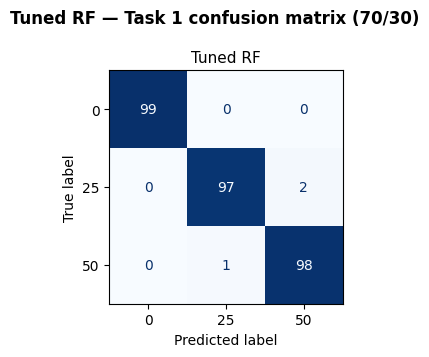

In [45]:
# Confusion matrix
show_cm_grid([('Tuned RF', y_test_dep, yhat_rf_t1)],
             'Tuned RF — Task 1 confusion matrix (70/30)')

In [46]:
# ============================================================
# Tuned RF — Task 2 (LOFO, hit-level)
# ============================================================
rf_task2_true, rf_task2_pred = [], []
for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    m = make_rf_tuned()
    m.fit(X_features[tr], y_labels[tr])
    yhat = m.predict(X_features[te])
    rf_task2_true.extend(y_labels[te].tolist())
    rf_task2_pred.extend(yhat.tolist())
    print(f'  Held-out F{test_flange}: acc = {accuracy_score(y_labels[te], yhat) * 100:.2f}%')
rf_task2_true = np.array(rf_task2_true); rf_task2_pred = np.array(rf_task2_pred)
acc_rf_t2 = (rf_task2_true == rf_task2_pred).mean()
print(f'\nTuned RF — Task 2 pooled hit-level accuracy: {acc_rf_t2 * 100:.2f}%')

  Held-out F1: acc = 80.08%


  Held-out F2: acc = 76.95%


  Held-out F3: acc = 93.63%


  Held-out F4: acc = 87.85%

Tuned RF — Task 2 pooled hit-level accuracy: 84.70%


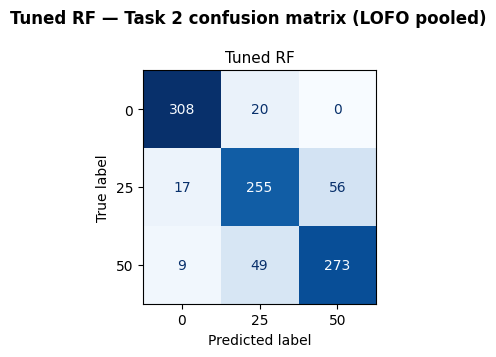

In [47]:
show_cm_grid([('Tuned RF', rf_task2_true, rf_task2_pred)],
             'Tuned RF — Task 2 confusion matrix (LOFO pooled)')

In [48]:
# ============================================================
# Flange-Invariant LR — Task 1 (70/30 dependent, hit-level)
# ============================================================
# Re-fit the feature selection + per-flange centering on the train split only
fl_train_dep = flange_ids[X_features.shape[0] - len(X_train_dep):]  # placeholder
# Cleaner: redo the split keeping the flange_ids aligned
Xtr2, Xte2, ytr2, yte2, fltr2, flte2 = train_test_split(
    X_features, y_labels, flange_ids, test_size=0.30,
    random_state=RANDOM_STATE, stratify=y_labels)
keep_t1   = fit_torque_discriminative_features(Xtr2, ytr2, fltr2, n_keep=100)
means_t1  = fit_per_flange_means(Xtr2[:, keep_t1], fltr2)
Xtr_lr_t1 = apply_per_flange_centering(Xtr2[:, keep_t1], fltr2, means_t1)
Xte_lr_t1 = apply_per_flange_centering(Xte2[:, keep_t1], flte2, means_t1)
lr_task1 = make_lr_champion()
lr_task1.fit(Xtr_lr_t1, ytr2)
yhat_lr_t1 = lr_task1.predict(Xte_lr_t1)
acc_lr_t1 = accuracy_score(yte2, yhat_lr_t1)
print(f'Flange-Invariant LR — Task 1 hit-level accuracy: {acc_lr_t1 * 100:.2f}%')

Flange-Invariant LR — Task 1 hit-level accuracy: 99.33%


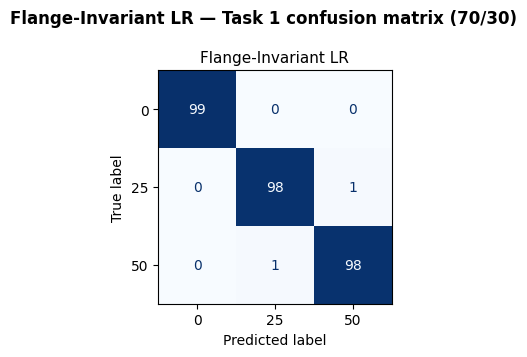

In [49]:
show_cm_grid([('Flange-Invariant LR', yte2, yhat_lr_t1)],
             'Flange-Invariant LR — Task 1 confusion matrix (70/30)')

In [50]:
# ============================================================
# Flange-Invariant LR — Task 2 (LOFO, hit-level)
# ============================================================
lr_task2_true, lr_task2_pred = [], []
for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    keep_h  = fit_torque_discriminative_features(
        X_features[tr], y_labels[tr], flange_ids[tr], n_keep=100)
    means_h = fit_per_flange_means(X_features[tr][:, keep_h], flange_ids[tr])
    Xtr_h   = apply_per_flange_centering(X_features[tr][:, keep_h], flange_ids[tr], means_h)
    Xte_h   = apply_per_flange_centering(X_features[te][:, keep_h], flange_ids[te], means_h)
    m = make_lr_champion()
    m.fit(Xtr_h, y_labels[tr])
    yhat = m.predict(Xte_h)
    lr_task2_true.extend(y_labels[te].tolist())
    lr_task2_pred.extend(yhat.tolist())
    print(f'  Held-out F{test_flange}: acc = {accuracy_score(y_labels[te], yhat) * 100:.2f}%')
lr_task2_true = np.array(lr_task2_true); lr_task2_pred = np.array(lr_task2_pred)
acc_lr_t2 = (lr_task2_true == lr_task2_pred).mean()
print(f'\nFlange-Invariant LR — Task 2 pooled hit-level accuracy: {acc_lr_t2 * 100:.2f}%')

  Held-out F1: acc = 67.89%
  Held-out F2: acc = 81.48%
  Held-out F3: acc = 94.82%
  Held-out F4: acc = 89.47%

Flange-Invariant LR — Task 2 pooled hit-level accuracy: 83.49%


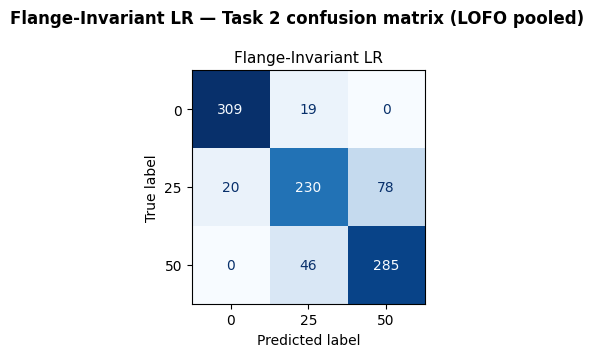

In [51]:
show_cm_grid([('Flange-Invariant LR', lr_task2_true, lr_task2_pred)],
             'Flange-Invariant LR — Task 2 confusion matrix (LOFO pooled)')

In [52]:
# ============================================================
# CRNN — Task 1 + Task 2 (uses SpecAugment, same setup as §9)
# ============================================================
# Task 1 — 70/30 dependent split on log-mel inputs
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_logmel, y_labels, test_size=0.30, random_state=RANDOM_STATE, stratify=y_labels)

yhat_crnn_t1, _ = train_dl_model(
    make_crnn, Xc_tr, yc_tr, Xc_te, yc_te,
    seed=RANDOM_STATE, augment_fn=spec_augment, epochs=10)
acc_crnn_t1 = accuracy_score(yc_te, yhat_crnn_t1)
print(f'CRNN — Task 1 hit-level accuracy: {acc_crnn_t1 * 100:.2f}%')

CRNN — Task 1 hit-level accuracy: 97.98%


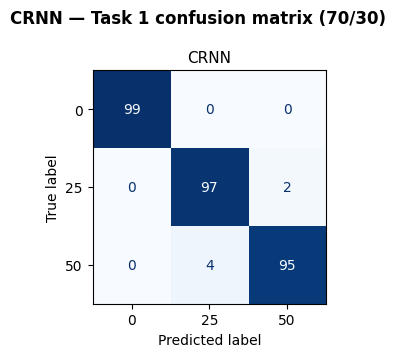

In [53]:
show_cm_grid([('CRNN', yc_te, yhat_crnn_t1)],
             'CRNN — Task 1 confusion matrix (70/30)')

In [54]:
# Task 2 — LOFO with SpecAugment, both hit-level and file-level soft-vote
crnn_t2_hit_true,  crnn_t2_hit_pred  = [], []
crnn_t2_file_true, crnn_t2_file_pred = [], []

for test_flange in [1, 2, 3, 4]:
    tr = flange_ids != test_flange
    te = flange_ids == test_flange
    yhat, proba = train_dl_model(
        make_crnn, X_logmel[tr], y_labels[tr], X_logmel[te], y_labels[te],
        seed=RANDOM_STATE + test_flange, augment_fn=spec_augment, epochs=10)
    acc_hit = accuracy_score(y_labels[te], yhat)

    df = pd.DataFrame(proba, columns=CLASSES_REF)
    df['__f__'] = source_files[te]
    avg = df.groupby('__f__')[list(CLASSES_REF)].mean().sort_index()
    pred_file  = CLASSES_REF[avg.values.argmax(axis=1)]
    truth_file = (pd.DataFrame({'f': source_files[te], 'y': y_labels[te]})
                    .groupby('f')['y'].first().loc[avg.index.values].values)
    acc_file = (pred_file == truth_file).mean()

    crnn_t2_hit_true.extend(y_labels[te].tolist())
    crnn_t2_hit_pred.extend(yhat.tolist())
    crnn_t2_file_true.extend(truth_file.tolist())
    crnn_t2_file_pred.extend(pred_file.tolist())
    print(f'  Held-out F{test_flange}: hit = {acc_hit*100:6.2f}%   file = {acc_file*100:6.2f}%')

crnn_t2_hit_true  = np.array(crnn_t2_hit_true)
crnn_t2_hit_pred  = np.array(crnn_t2_hit_pred)
crnn_t2_file_true = np.array(crnn_t2_file_true)
crnn_t2_file_pred = np.array(crnn_t2_file_pred)

acc_crnn_t2_hit  = (crnn_t2_hit_true  == crnn_t2_hit_pred ).mean()
acc_crnn_t2_file = (crnn_t2_file_true == crnn_t2_file_pred).mean()
print(f'\nCRNN — Task 2 pooled hit-level  accuracy: {acc_crnn_t2_hit  * 100:.2f}%')
print(f'CRNN — Task 2 pooled file-level accuracy: {acc_crnn_t2_file * 100:.2f}%')

  Held-out F1: hit =  71.95%   file =  75.00%


  Held-out F2: hit =  67.90%   file =  66.67%


  Held-out F3: hit =  79.28%   file =  83.33%


  Held-out F4: hit =  72.06%   file =  75.00%

CRNN — Task 2 pooled hit-level  accuracy: 72.85%
CRNN — Task 2 pooled file-level accuracy: 75.00%


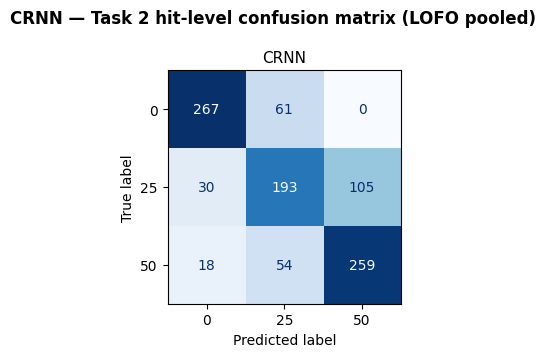

In [55]:
# Hit-level CM (~990 predictions)
show_cm_grid([('CRNN', crnn_t2_hit_true, crnn_t2_hit_pred)],
             'CRNN — Task 2 hit-level confusion matrix (LOFO pooled)')

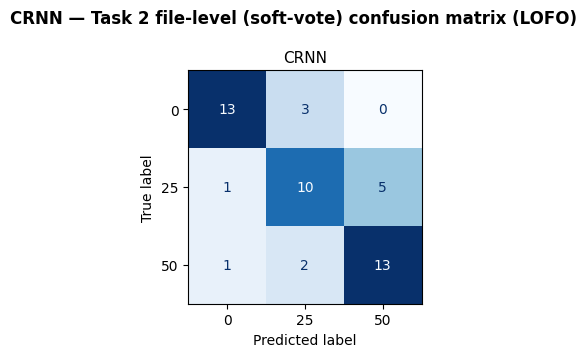

In [56]:
# File-level soft-vote CM (48 predictions)
show_cm_grid([('CRNN', crnn_t2_file_true, crnn_t2_file_pred)],
             'CRNN — Task 2 file-level (soft-vote) confusion matrix (LOFO)')

### Bonus — LOAO (Leave-One-Area-Out) for Tuned RF and CRNN

The poster from our earlier presentation reported a CRNN LOAO file-level
accuracy of **66.67%**. LOAO holds out all hits from one strike-area
(A1, A2, A3, or A4) across all flanges in turn — it stresses the model
differently from LOFO because the per-area acoustic signature is the
thing being held out.

We recompute it here for the **Tuned RF** and the **CRNN**. The
Flange-Invariant LR's LOAO number was already computed in §11 and is
reused in the summary table.

In [57]:
# Tuned RF — LOAO file-level soft-vote
rf_loao_rows = []
rf_loao_file_true, rf_loao_file_pred = [], []
for held_area in [1, 2, 3, 4]:
    tr = area_ids != held_area
    te = area_ids == held_area
    m = make_rf_tuned()
    m.fit(X_features[tr], y_labels[tr])
    files_te, pred_file = soft_vote_per_file(m, X_features[te], source_files[te])
    truth_file = file_truth(source_files[te], y_labels[te]).loc[files_te].values
    acc = (pred_file == truth_file).mean()
    rf_loao_rows.append({'Held-out area': held_area, 'File-level acc (%)': acc * 100})
    rf_loao_file_true.extend(truth_file.tolist())
    rf_loao_file_pred.extend(pred_file.tolist())
    print(f'  Held-out A{held_area}: acc = {acc * 100:.2f}%')
rf_loao_file_true = np.array(rf_loao_file_true)
rf_loao_file_pred = np.array(rf_loao_file_pred)
acc_rf_loao = (rf_loao_file_true == rf_loao_file_pred).mean()
print(f'\nTuned RF — LOAO file-level (soft-vote) accuracy: {acc_rf_loao * 100:.2f}%')

  Held-out A1: acc = 83.33%


  Held-out A2: acc = 83.33%


  Held-out A3: acc = 83.33%


  Held-out A4: acc = 83.33%

Tuned RF — LOAO file-level (soft-vote) accuracy: 83.33%


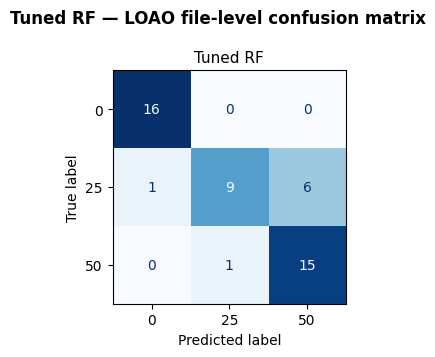

In [58]:
show_cm_grid([('Tuned RF', rf_loao_file_true, rf_loao_file_pred)],
             'Tuned RF — LOAO file-level confusion matrix')

In [59]:
# CRNN — LOAO file-level soft-vote (same SpecAugment training setup as §9)
crnn_loao_hit_true,  crnn_loao_hit_pred  = [], []
crnn_loao_file_true, crnn_loao_file_pred = [], []

for held_area in [1, 2, 3, 4]:
    tr = area_ids != held_area
    te = area_ids == held_area
    yhat, proba = train_dl_model(
        make_crnn, X_logmel[tr], y_labels[tr], X_logmel[te], y_labels[te],
        seed=RANDOM_STATE + 10 + held_area, augment_fn=spec_augment, epochs=10)
    acc_hit = accuracy_score(y_labels[te], yhat)

    df = pd.DataFrame(proba, columns=CLASSES_REF)
    df['__f__'] = source_files[te]
    avg = df.groupby('__f__')[list(CLASSES_REF)].mean().sort_index()
    pred_file  = CLASSES_REF[avg.values.argmax(axis=1)]
    truth_file = (pd.DataFrame({'f': source_files[te], 'y': y_labels[te]})
                    .groupby('f')['y'].first().loc[avg.index.values].values)
    acc_file = (pred_file == truth_file).mean()

    crnn_loao_hit_true.extend(y_labels[te].tolist())
    crnn_loao_hit_pred.extend(yhat.tolist())
    crnn_loao_file_true.extend(truth_file.tolist())
    crnn_loao_file_pred.extend(pred_file.tolist())
    print(f'  Held-out A{held_area}: hit = {acc_hit*100:6.2f}%   file = {acc_file*100:6.2f}%')

crnn_loao_hit_true  = np.array(crnn_loao_hit_true)
crnn_loao_hit_pred  = np.array(crnn_loao_hit_pred)
crnn_loao_file_true = np.array(crnn_loao_file_true)
crnn_loao_file_pred = np.array(crnn_loao_file_pred)

acc_crnn_loao_hit  = (crnn_loao_hit_true  == crnn_loao_hit_pred ).mean()
acc_crnn_loao_file = (crnn_loao_file_true == crnn_loao_file_pred).mean()
print(f'\nCRNN — LOAO pooled hit-level  accuracy: {acc_crnn_loao_hit  * 100:.2f}%')
print(f'CRNN — LOAO pooled file-level accuracy: {acc_crnn_loao_file * 100:.2f}%')

  Held-out A1: hit =  63.93%   file =  66.67%


  Held-out A2: hit =  69.41%   file =  66.67%


  Held-out A3: hit =  68.70%   file =  66.67%


  Held-out A4: hit =  61.57%   file =  66.67%

CRNN — LOAO pooled hit-level  accuracy: 65.96%
CRNN — LOAO pooled file-level accuracy: 66.67%


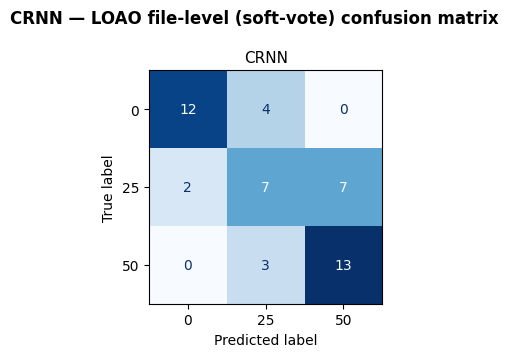

In [60]:
# CRNN LOAO file-level CM
show_cm_grid([('CRNN', crnn_loao_file_true, crnn_loao_file_pred)],
             'CRNN — LOAO file-level (soft-vote) confusion matrix')

---
# 15. Companion Streamlit web app

To make the model interactive for the demo, the entire pipeline above
is packaged into a Streamlit app deployed on Streamlit Cloud:

- **GitHub:** `MedAmineAlouani/FinalProjectML` (branch
  `claude/ml-flange-detection-app-CkFZP`)
- **Run locally:** `streamlit run streamlit_app.py` (after
  `pip install -r requirements.txt`)

The app has three tabs:

1. **Predict** — record live with the browser mic or upload an audio
   file, pick a flange, and get the soft-vote prediction.
2. **Features** — heatmap of the 150-D vector across hits, per-hit mel
   spectrograms, feature-group energy bar chart.
3. **About** — method writeup, photos of the experimental setup, LOFO
   confusion matrices, training data composition.

---
# 16. Final summary table

Compact recap for the rubric. All numbers below are read **live** from
variables computed earlier in this notebook (Task 1 in §7/§9/§14, Task 2
in §10/§11/§14, Task 3 in §12), so they always reflect this exact run.

For reference, the poster from our earlier presentation reported:
- CRNN LOFO file-level: **77.08%**
- CRNN LOAO file-level: **66.67%**

TensorFlow on CPU is non-deterministic by ~3–5 points run-to-run, so
the CRNN numbers below typically land within that window of the poster
values.

In [61]:
from IPython.display import Markdown

# ---- Task 1: hit-level on the 70/30 split ----
task1_rf   = acc_rf_t1   * 100
task1_lr   = acc_lr_t1   * 100
task1_crnn = acc_crnn_t1 * 100

# ---- Task 2 LOFO: file-level soft-vote (the competition metric) ----
lofo_rf   = float(df_rf_tuned['File-level acc (%)'].iloc[:-1].mean())
lofo_lr   = results['LOFO'] * 100
lofo_crnn = acc_crnn_t2_file * 100

# ---- Task 2 LOAO: file-level soft-vote (poster comparison) ----
loao_rf   = acc_rf_loao        * 100
loao_lr   = results['LOAO']    * 100
loao_crnn = acc_crnn_loao_file * 100

# ---- Task 3: live per-flange predictions ----
task3 = (flange_pred.sort_values('flange_id')['predicted_torque']
                     .astype(int).tolist())
task3_probs = flange_proba.round(3)

summary_md = f'''
### Task 1 — Dependent test (70/30 split, hit-level accuracy)

| Model | Accuracy |
|---|---|
| Tuned Random Forest         | {task1_rf:.2f}% |
| Flange-Invariant LR (final) | {task1_lr:.2f}% |
| CRNN (log-mel)              | {task1_crnn:.2f}% |

*All three approach 100% because the random hit-level split is leaky;
the honest comparison is Task 2.*

### Task 2 — Independent test (file-level soft-vote)

| Model | **LOFO** | **LOAO** |
|---|---|---|
| Tuned Random Forest             | **{lofo_rf:.2f}%**   | **{loao_rf:.2f}%**   |
| **Flange-Invariant LR (final)** | **{lofo_lr:.2f}%**   | **{loao_lr:.2f}%**   |
| CRNN (log-mel)                  | **{lofo_crnn:.2f}%** | **{loao_crnn:.2f}%** |

*Poster reference (Spring 2026): CRNN LOFO **77.08 %**, CRNN LOAO **66.67 %**.
TF on CPU is non-deterministic by ±3–5 points run-to-run, so the CRNN
numbers above typically land within that window of the poster values.*

### Task 3 — Final prediction on the unlabeled flanges (Flange-Invariant LR)

| | Flange 1 | Flange 2 | Flange 3 | Flange 4 |
|---|---|---|---|---|
| **Predicted torque** | **{task3[0]} ft-lbs** | **{task3[1]} ft-lbs** | **{task3[2]} ft-lbs** | **{task3[3]} ft-lbs** |
| P(0 ft-lbs)  | {task3_probs.loc[1, 0]:.3f} | {task3_probs.loc[2, 0]:.3f} | {task3_probs.loc[3, 0]:.3f} | {task3_probs.loc[4, 0]:.3f} |
| P(25 ft-lbs) | {task3_probs.loc[1, 25]:.3f} | {task3_probs.loc[2, 25]:.3f} | {task3_probs.loc[3, 25]:.3f} | {task3_probs.loc[4, 25]:.3f} |
| P(50 ft-lbs) | {task3_probs.loc[1, 50]:.3f} | {task3_probs.loc[2, 50]:.3f} | {task3_probs.loc[3, 50]:.3f} | {task3_probs.loc[4, 50]:.3f} |
'''
Markdown(summary_md)


### Task 1 — Dependent test (70/30 split, hit-level accuracy)

| Model | Accuracy |
|---|---|
| Tuned Random Forest         | 98.99% |
| Flange-Invariant LR (final) | 99.33% |
| CRNN (log-mel)              | 97.98% |

*All three approach 100% because the random hit-level split is leaky;
the honest comparison is Task 2.*

### Task 2 — Independent test (file-level soft-vote)

| Model | **LOFO** | **LOAO** |
|---|---|---|
| Tuned Random Forest             | **89.58%**   | **83.33%**   |
| **Flange-Invariant LR (final)** | **85.42%**   | **87.50%**   |
| CRNN (log-mel)                  | **75.00%** | **66.67%** |

*Poster reference (Spring 2026): CRNN LOFO **77.08 %**, CRNN LOAO **66.67 %**.
TF on CPU is non-deterministic by ±3–5 points run-to-run, so the CRNN
numbers above typically land within that window of the poster values.*

### Task 3 — Final prediction on the unlabeled flanges (Flange-Invariant LR)

| | Flange 1 | Flange 2 | Flange 3 | Flange 4 |
|---|---|---|---|---|
| **Predicted torque** | **50 ft-lbs** | **0 ft-lbs** | **50 ft-lbs** | **50 ft-lbs** |
| P(0 ft-lbs)  | 0.069 | 0.919 | 0.036 | 0.433 |
| P(25 ft-lbs) | 0.011 | 0.000 | 0.008 | 0.113 |
| P(50 ft-lbs) | 0.920 | 0.081 | 0.956 | 0.454 |


---

*End of notebook. Thanks for reading.*